# 📊 Fundamentos de Pandas, Visualización y Estadística Descriptiva

## Universidad de Antioquia — Pregrado en Ciencia Política

**Cuaderno interactivo** diseñado para estudiantes que ya completaron los fundamentos de Python y cuentan con bases en estadística descriptiva.

---

### 🎯 Objetivo

Dominar las herramientas fundamentales del **análisis cuantitativo** en Python: cómo cargar, manipular y resumir datos con **pandas**, cómo visualizarlos con **matplotlib** y **seaborn**, y cómo calcular e interpretar los **estadísticos descriptivos** (medidas de tendencia central, dispersión y posición) que ya conoces de tu curso de estadística.

Al terminar este cuaderno serás capaz de:
- Cargar un dataset desde un archivo CSV y explorarlo
- Seleccionar, filtrar y transformar datos con pandas
- Crear visualizaciones informativas (histogramas, barras, boxplots, scatterplots)
- Calcular e interpretar media, mediana, moda, desviación estándar, varianza, cuartiles, percentiles y sesgo
- Comparar distribuciones entre grupos (el corazón del análisis político)

---

### 📦 Prerrequisitos
- Haber completado `02_fundamentos_python.ipynb` (variables, tipos de datos, bucles, condicionales, listas, diccionarios)
- Conceptos básicos de estadística descriptiva (medidas de tendencia central, dispersión y posición)

### 🗺️ Estructura del cuaderno

| Bloque | Temas | Contenido |
|---|---|---|
| **I** | 01–04 | Pandas: Series, DataFrames, carga y exploración de datos |
| **II** | 05–08 | Manipulación: selección, filtrado, nuevas columnas, agrupación |
| **III** | 09–12 | Estadística descriptiva: centralidad, dispersión, posición, sesgo |
| **IV** | 13–16 | Visualización: histogramas, barras, boxplots, scatterplots y mapas de calor |

---

> **Cómo trabajar:** Lee la explicación, ejecuta cada celda de código y luego resuelve el desafío (⚠️). Escribe el código tú mismo/a — no copies y pegues.

---
## 🔧 Instalación y preparación del entorno

Antes de empezar, asegurémonos de que las librerías necesarias estén instaladas. Si ya las tienes, esta celda no hará daño. Si no, las instalará.

In [168]:
# Ejecuta esta celda una sola vez para asegurar que las librerías estén disponibles
# Si ya están instaladas, simplemente confirmará la versión

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(f"pandas:     {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn:    {sns.__version__}")
print(f"numpy:      {np.__version__}")
print("\nTodas las librerías cargadas correctamente.")

pandas:     3.0.1
matplotlib: 3.10.8
seaborn:    0.13.2
numpy:      2.4.2

Todas las librerías cargadas correctamente.


---
## 📋 Dataset de trabajo: Elecciones Municipales en Antioquia

A lo largo de todo este cuaderno usaremos un dataset simulado de resultados electorales de municipios antioqueños. 

---
# BLOQUE I — Pandas: Fundamentos
---

# Tema 01 — ¿Qué es pandas? Series y DataFrames

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **pandas** | Librería de Python para manipular datos tabulares. Es el equivalente a Excel, SPSS o Stata, pero con la potencia de la programación. |
| **Series** | Una sola columna de datos con índice. Como una lista, pero con etiquetas. |
| **DataFrame** | Una tabla completa: filas × columnas. Es la estructura central de pandas. |
| **`import pandas as pd`** | Cargamos pandas y le damos el alias `pd` para escribir menos. Es una convención universal. |

### 🎯 Analogía para politólogos
- Un **DataFrame** es como una hoja de Excel donde cada fila es una **unidad de análisis** (un municipio, un votante, un país) y cada columna es una **variable** (población, participación, NBI).
- Una **Series** es una sola columna de esa hoja.

In [169]:
import pandas as pd

# === SERIES: Una columna de datos con etiquetas ===
# Imagina una columna de una tabla con resultados electorales
votos = pd.Series([1012500, 189500, 115400, 109200, 62700],
                  index=["Medellín", "Bello", "Envigado", "Itagüí", "Rionegro"])

print("=== Serie: Votantes por municipio ===")
print(votos)
print(f"\nTipo: {type(votos)}")
print(f"Valores: {votos.values}")    # Solo los números (array de NumPy)
print(f"Índice: {votos.index.tolist()}")  # Solo las etiquetas

=== Serie: Votantes por municipio ===
Medellín    1012500
Bello        189500
Envigado     115400
Itagüí       109200
Rionegro      62700
dtype: int64

Tipo: <class 'pandas.Series'>
Valores: [1012500  189500  115400  109200   62700]
Índice: ['Medellín', 'Bello', 'Envigado', 'Itagüí', 'Rionegro']


In [170]:
# Acceder a elementos de una Series
print("Votos en Medellín:", votos["Medellín"])      # Por etiqueta
print("Votos en Medellín:", votos.iloc[0])           # Por posición (0 = primero)
print("Primeros 3:", votos.head(3).tolist())         # Los primeros 3 valores

# Operaciones sobre toda la Series a la vez
print(f"\nTotal de votos: {votos.sum():,}")
print(f"Promedio: {votos.mean():,.0f}")
print(f"Máximo: {votos.max():,} ({votos.idxmax()})")
print(f"Mínimo: {votos.min():,} ({votos.idxmin()})")

Votos en Medellín: 1012500
Votos en Medellín: 1012500
Primeros 3: [1012500, 189500, 115400]

Total de votos: 1,489,300
Promedio: 297,860
Máximo: 1,012,500 (Medellín)
Mínimo: 62,700 (Rionegro)


In [171]:
# === DATAFRAME: La tabla completa ===
# Se crea a partir de un diccionario: cada clave es una columna

datos = {
    "municipio": ["Medellín", "Bello", "Envigado", "Itagüí", "Rionegro"],
    "habilitados": [1823000, 412000, 178000, 195000, 98000],
    "votantes": [1012500, 189500, 115400, 109200, 62700],
    "subregion": ["Valle de Aburrá", "Valle de Aburrá", "Valle de Aburrá", "Valle de Aburrá", "Oriente"]
}

ejemplo_df = pd.DataFrame(datos)

print("=== DataFrame: Resultados Electorales ===")
print(ejemplo_df)

print("=== || ===")
print(f"\nTipo: {type(ejemplo_df)}")
print("\n=== || ===\n")

print(f"Forma (filas, columnas): {ejemplo_df.shape}")

=== DataFrame: Resultados Electorales ===
  municipio  habilitados  votantes        subregion
0  Medellín      1823000   1012500  Valle de Aburrá
1     Bello       412000    189500  Valle de Aburrá
2  Envigado       178000    115400  Valle de Aburrá
3    Itagüí       195000    109200  Valle de Aburrá
4  Rionegro        98000     62700          Oriente
=== || ===

Tipo: <class 'pandas.DataFrame'>

=== || ===

Forma (filas, columnas): (5, 4)


In [172]:
# === Acceder a columnas de un DataFrame ===

# Forma 1: con corchetes y comillas (SIEMPRE funciona)
print(ejemplo_df["municipio"])
print()

# Forma 2: con punto (funciona solo si el nombre no tiene espacios ni caracteres especiales)
print(ejemplo_df.municipio)

# ⚠️ Cada columna de un DataFrame es una Series
print(f"\nTipo de una columna: {type(ejemplo_df['votantes'])}")

0    Medellín
1       Bello
2    Envigado
3      Itagüí
4    Rionegro
Name: municipio, dtype: str

0    Medellín
1       Bello
2    Envigado
3      Itagüí
4    Rionegro
Name: municipio, dtype: str

Tipo de una columna: <class 'pandas.Series'>


### ⚠️ Desafío
Crea un DataFrame con datos de 4 partidos políticos colombianos. Incluye las columnas: `partido`, `votos_senado`, `curules` y `supero_umbral` (booleano). Imprime el DataFrame y verifica su forma con `.shape`.

### 📝 TL;DR
- **pandas** se importa como `pd`. Es la herramienta central para trabajar con datos tabulares.
- Una **Series** es una columna con etiquetas. Un **DataFrame** es una tabla (filas × columnas).
- Se crean DataFrames desde diccionarios: `pd.DataFrame({"col1": [...], "col2": [...]})`.
- Cada columna de un DataFrame es una Series.

In [173]:
# Tu código aquí


---
# Tema 02 — Cargar datos desde archivos: `read_csv()`

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **CSV** | Archivo de texto donde las columnas están separadas por comas (Comma-Separated Values). Es el formato más universal para compartir datos. |
| **`pd.read_csv()`** | Función que lee un archivo CSV y lo convierte en un DataFrame. |
| **`encoding`** | Parámetro que indica cómo están codificados los caracteres. En Colombia, si hay tildes o ñ, a veces necesitas `encoding='latin-1'` o `encoding='utf-8'`. |

### 🎯 En ciencia política
La mayoría de los datos públicos en Colombia (Registraduría, DANE, DNP, SISBEN) se descargan como CSV o Excel. Saber cargarlos es el **primer paso** de cualquier análisis.

In [174]:
# === Cargar un CSV ===
# El archivo 'elecciones_antioquia.csv' fue creado arriba
df = pd.read_csv("elecciones_antioquia_random.csv")

# Confirmar que se cargó
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print()
print(f"Columnas: {df.columns}")
print()
print(f"Columnas: {df.columns.tolist()}")

Dataset cargado: 25 filas × 10 columnas

Columnas: Index(['municipio', 'subregion', 'poblacion', 'habilitados', 'votantes',
       'votos_nulos', 'categoria_municipio', 'indice_ruralidad',
       'presencia_armada', 'NBI'],
      dtype='str')

Columnas: ['municipio', 'subregion', 'poblacion', 'habilitados', 'votantes', 'votos_nulos', 'categoria_municipio', 'indice_ruralidad', 'presencia_armada', 'NBI']


In [175]:
# === Las 5 inspecciones que SIEMPRE debes hacer al recibir un dataset ===

# 1. Primeras filas → ¿Cómo se ven los datos?
print("=== 1. head(): Primeras filas ===")
df.head(3)  # En Jupyter, la última línea de la celda se muestra como tabla bonita

=== 1. head(): Primeras filas ===


,municipio,subregion,poblacion,habilitados,votantes,votos_nulos,categoria_municipio,indice_ruralidad,presencia_armada,NBI
0,Medellín,Valle de Aburrá,2569007,1823000,1012500,18230,Especial,0.12,False,12.3
1,Bello,Valle de Aburrá,678125,412000,189500,4120,1,0.18,False,18.7
2,Envigado,Valle de Aburrá,252478,178000,115400,1780,2,0.08,False,8.4


In [176]:
# 2. Dimensiones → ¿Cuántas observaciones y variables tengo?
print("=== 2. shape: Dimensiones ===")
print(f"Filas (observaciones): {df.shape[0]}")
print(f"Columnas (variables):  {df.shape[1]}")

=== 2. shape: Dimensiones ===
Filas (observaciones): 25
Columnas (variables):  10


In [177]:
# 3. Tipos de datos → ¿Python interpretó correctamente cada variable?
print("=== 3. dtypes: Tipos de datos ===")
print(df.dtypes)
# int64 = entero, float64 = decimal, object = texto, bool = verdadero/falso

=== 3. dtypes: Tipos de datos ===
municipio                  str
subregion                  str
poblacion                int64
habilitados              int64
votantes                 int64
votos_nulos              int64
categoria_municipio        str
indice_ruralidad       float64
presencia_armada          bool
NBI                    float64
dtype: object


In [178]:
# 4. Info general → Todo junto (tipos, no-nulos, memoria)
print("=== 4. info(): Resumen estructural ===")
df.info()

=== 4. info(): Resumen estructural ===
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   municipio            25 non-null     str    
 1   subregion            25 non-null     str    
 2   poblacion            25 non-null     int64  
 3   habilitados          25 non-null     int64  
 4   votantes             25 non-null     int64  
 5   votos_nulos          25 non-null     int64  
 6   categoria_municipio  25 non-null     str    
 7   indice_ruralidad     25 non-null     float64
 8   presencia_armada     25 non-null     bool   
 9   NBI                  25 non-null     float64
dtypes: bool(1), float64(2), int64(4), str(3)
memory usage: 1.9 KB


In [179]:
# 5. Valores faltantes → ¿Hay datos que faltan?
# En ciencia política esto es CRÍTICO: los datos faltantes no son aleatorios.
# ¿Faltan datos de municipios con presencia armada? Eso ya es un hallazgo.
print("=== 5. Valores faltantes ===")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

=== 5. Valores faltantes ===
municipio              0
subregion              0
poblacion              0
habilitados            0
votantes               0
votos_nulos            0
categoria_municipio    0
indice_ruralidad       0
presencia_armada       0
NBI                    0
dtype: int64

Total de valores faltantes: 0


### ⚠️ Desafío
Ejecuta `df.tail(5)` para ver las últimas 5 filas. Luego ejecuta `df.sample(3)` para ver 3 filas aleatorias. ¿Qué ventaja tiene `sample()` sobre `head()` al explorar datos? Piensa en un escenario con datos ordenados por departamento.

### 📝 TL;DR
- `pd.read_csv("archivo.csv")` carga un archivo CSV como DataFrame.
- Las 5 inspecciones obligatorias: `head()`, `shape`, `dtypes`, `info()`, `isnull().sum()`.
- Siempre revisa los tipos de datos: pandas a veces interpreta números como texto si hay errores en el archivo.
- Los valores faltantes se detectan con `isnull()` y se cuentan con `.sum()`.

In [180]:
# Tu código aquí


---
# Tema 03 — Estadísticos rápidos con `describe()` y `value_counts()`

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **`describe()`** | Genera un resumen estadístico automático: media, desviación estándar, mínimo, máximo y cuartiles. Solo para columnas numéricas. |
| **`value_counts()`** | Cuenta cuántas veces aparece cada valor en una columna categórica. Equivale a una tabla de frecuencias. |
| **Variable numérica** | Tiene sentido calcular su promedio (edad, población, votos). |
| **Variable categórica** | Representa categorías (subregión, sexo, partido). No tiene sentido promediarla. |

### 🎯 Regla de oro del politólogo cuantitativo
**El tipo de variable determina qué estadístico usar.** No calcules el promedio de una variable categórica. No hagas una tabla de frecuencias de una variable continua (al menos no sin agruparla primero).

In [181]:
# === describe(): Resumen estadístico de variables numéricas ===
print("=== Estadísticos descriptivos automáticos ===")
df.describe().round(1)

=== Estadísticos descriptivos automáticos ===


,poblacion,habilitados,votantes,votos_nulos,indice_ruralidad,NBI
count,25.0,25.0,25.0,25.0,25.0,25.0
mean,200271.7,132988.0,71409.6,1556.9,0.6,33.8
std,513942.8,362951.4,200901.3,3607.0,0.2,19.2
min,7234.0,5200.0,3796.0,52.0,0.1,8.4
25%,24567.0,16000.0,8750.0,240.0,0.5,19.8
50%,52100.0,31000.0,17670.0,510.0,0.6,28.5
75%,134567.0,76500.0,29400.0,1530.0,0.7,42.1
max,2569007.0,1823000.0,1012500.0,18230.0,0.9,78.9


In [182]:
# Leer la tabla de describe():
#   count = observaciones (si es menor que el total, hay datos faltantes)
#   mean  = promedio (media aritmética)
#   std   = desviación estándar (dispersión alrededor de la media)
#   min   = valor mínimo
#   25%   = primer cuartil (Q1): el 25% de los datos está por debajo
#   50%   = mediana (Q2): el 50% está por debajo
#   75%   = tercer cuartil (Q3): el 75% está por debajo
#   max   = valor máximo

# Podemos personalizar los percentiles
print("=== describe() con percentiles personalizados ===")
df[["poblacion", "votantes", "NBI"]].describe(percentiles=[.10, .25, .50, .75, .90]).round(1)

=== describe() con percentiles personalizados ===


,poblacion,votantes,NBI
count,25.0,25.0,25.0
mean,200271.7,71409.6,33.8
std,513942.8,200901.3,19.2
min,7234.0,3796.0,8.4
10%,15496.2,6045.6,14.8
25%,24567.0,8750.0,19.8
50%,52100.0,17670.0,28.5
75%,134567.0,29400.0,42.1
90%,277904.2,112920.0,64.0
max,2569007.0,1012500.0,78.9


In [183]:
# === value_counts(): Tabla de frecuencias para variables categóricas ===

# ¿Cuántos municipios hay por subregión?
print("=== Frecuencias: Municipios por subregión ===")
print(df["subregion"].value_counts())

print("\n=== Proporciones (porcentajes) ===")
# normalize=True devuelve proporciones en lugar de conteos
print((df["subregion"].value_counts(normalize=True) * 100).round(1))

=== Frecuencias: Municipios por subregión ===
subregion
Oriente            6
Valle de Aburrá    4
Suroeste           4
Bajo Cauca         3
Norte              3
Urabá              2
Nordeste           2
Occidente          1
Name: count, dtype: int64

=== Proporciones (porcentajes) ===
subregion
Oriente            24.0
Valle de Aburrá    16.0
Suroeste           16.0
Bajo Cauca         12.0
Norte              12.0
Urabá               8.0
Nordeste            8.0
Occidente           4.0
Name: proportion, dtype: float64


In [184]:
# Construir una tabla de frecuencias completa 
freq = df["subregion"].value_counts()
prop = df["subregion"].value_counts(normalize=True) * 100

tabla_frecuencias = pd.DataFrame({
    "Frecuencia": freq,
    "Porcentaje (%)": prop.round(1)
})

print("=== Tabla de Frecuencias: Subregión ===")
print(tabla_frecuencias)

=== Tabla de Frecuencias: Subregión ===
                 Frecuencia  Porcentaje (%)
subregion                                  
Oriente                   6            24.0
Valle de Aburrá           4            16.0
Suroeste                  4            16.0
Bajo Cauca                3            12.0
Norte                     3            12.0
Urabá                     2             8.0
Nordeste                  2             8.0
Occidente                 1             4.0


In [185]:
# === value_counts() también para booleanos ===
print("=== Presencia de grupos armados ===")
print(df["presencia_armada"].value_counts())
pct_armada = df["presencia_armada"].mean() * 100  # True=1, False=0
print(f"\n{pct_armada:.0f}% de los municipios tienen presencia de grupos armados")

=== Presencia de grupos armados ===
presencia_armada
False    18
True      7
Name: count, dtype: int64

28% de los municipios tienen presencia de grupos armados


### ⚠️ Desafío
1. Usa `describe()` solo sobre la columna `NBI` (Necesidades Básicas Insatisfechas). ¿Cuál es el municipio con el NBI más alto? Pista: `df["NBI"].describe()` te da el máximo; luego puedes buscar qué fila tiene ese valor.
2. Construye una tabla de frecuencias para `categoria_municipio`.

### 📝 TL;DR
- `describe()` = resumen estadístico automático para variables numéricas.
- `value_counts()` = tabla de frecuencias para variables categóricas.
- `value_counts(normalize=True)` devuelve proporciones en lugar de conteos.
- **Nunca calcules un promedio de una variable categórica.**

In [186]:
# Tu código aquí


---
# Tema 04 — Estadísticos individuales: `.mean()`, `.median()`, `.std()`, `.min()`, `.max()`

### 🧠 Conceptos clave

| Método | Qué calcula | Ejemplo |
|---|---|---|
| `.mean()` | Media aritmética (promedio) | `df["NBI"].mean()` |
| `.median()` | Mediana (valor central) | `df["NBI"].median()` |
| `.mode()` | Moda (valor más frecuente) | `df["subregion"].mode()` |
| `.std()` | Desviación estándar | `df["NBI"].std()` |
| `.var()` | Varianza | `df["NBI"].var()` |
| `.min()` / `.max()` | Mínimo / Máximo | `df["NBI"].min()` |
| `.sum()` | Suma total | `df["votantes"].sum()` |
| `.count()` | Conteo de no-nulos | `df["NBI"].count()` |
| `.skew()` | Sesgo (asimetría) | `df["NBI"].skew()` |
| `.quantile(q)` | Percentil/cuartil | `df["NBI"].quantile(0.75)` |

Todos estos métodos se pueden aplicar sobre una **Serie** (una columna) o sobre un **DataFrame completo** (en cuyo caso se aplica a cada columna numérica).

In [187]:
# === Calcular estadísticos sobre una columna (Serie) ===

print("=== Estadísticos del NBI (Necesidades Básicas Insatisfechas) ===")
print(f"Observaciones : {df['NBI'].count()}")
print(f"Media         : {df['NBI'].mean():.2f}")
print(f"Mediana       : {df['NBI'].median():.2f}")
print(f"Moda          : {df['NBI'].mode().values}")
print(f"Desv. estándar: {df['NBI'].std():.2f}")
print(f"Varianza      : {df['NBI'].var():.2f}")
print(f"Mínimo        : {df['NBI'].min():.2f}")
print(f"Máximo        : {df['NBI'].max():.2f}")
print(f"Rango         : {df['NBI'].max() - df['NBI'].min():.2f}")
print(f"Sesgo         : {df['NBI'].skew():.3f}")

=== Estadísticos del NBI (Necesidades Básicas Insatisfechas) ===
Observaciones : 25
Media         : 33.81
Mediana       : 28.50
Moda          : [ 8.4 12.3 14.2 15.6 16.8 18.7 19.8 22.4 24.1 25.3 26.8 27.3 28.5 30.7
 31.2 32.1 35.6 38.2 42.1 45.7 52.1 58.3 67.8 72.4 78.9]
Desv. estándar: 19.17
Varianza      : 367.46
Mínimo        : 8.40
Máximo        : 78.90
Rango         : 70.50
Sesgo         : 1.007


In [188]:
# === Cuartiles y percentiles ===

print("=== Cuartiles de la participación electoral ===")

# Primero calculamos la participación
participacion = (df["votantes"] / df["habilitados"]) * 100

print(f"Q1 (25%): {participacion.quantile(0.25):.2f}%")
print(f"Q2 (50%): {participacion.quantile(0.50):.2f}%  ← Esto es la mediana")
print(f"Q3 (75%): {participacion.quantile(0.75):.2f}%")

# Rango intercuartílico (IQR)
iqr = participacion.quantile(0.75) - participacion.quantile(0.25)
print(f"\nIQR (Q3 - Q1): {iqr:.2f} puntos porcentuales")
print("El IQR nos dice cuán disperso está el 50% central de los datos")

# Percentiles personalizados
print(f"\nPercentil 10: {participacion.quantile(0.10):.2f}%")
print(f"Percentil 90: {participacion.quantile(0.90):.2f}%")

=== Cuartiles de la participación electoral ===
Q1 (25%): 48.00%
Q2 (50%): 59.00%  ← Esto es la mediana
Q3 (75%): 66.00%

IQR (Q3 - Q1): 18.00 puntos porcentuales
El IQR nos dice cuán disperso está el 50% central de los datos

Percentil 10: 30.73%
Percentil 90: 70.00%


In [189]:
# === Aplicar estadísticos a varias columnas a la vez ===

# Seleccionar solo columnas numéricas de interés
vars_numericas = ["poblacion", "habilitados", "votantes", "NBI", "indice_ruralidad"]

print("=== Media de cada variable ===")
print(df[vars_numericas].mean().round(2))

print("\n=== Mediana de cada variable ===")
print(df[vars_numericas].median().round(2))

print("\n💡 Compara media vs mediana: cuando difieren mucho,")
print("   la distribución está sesgada (hay valores extremos que 'jalan' el promedio).")
print(f"   Ejemplo: población media = {df['poblacion'].mean():,.0f}")
print(f"            población mediana = {df['poblacion'].median():,.0f}")
print("   Medellín 'jala' el promedio hacia arriba.")

=== Media de cada variable ===
poblacion           200271.68
habilitados         132988.00
votantes             71409.60
NBI                     33.81
indice_ruralidad         0.55
dtype: float64

=== Mediana de cada variable ===
poblacion           52100.00
habilitados         31000.00
votantes            17670.00
NBI                    28.50
indice_ruralidad        0.62
dtype: float64

💡 Compara media vs mediana: cuando difieren mucho,
   la distribución está sesgada (hay valores extremos que 'jalan' el promedio).
   Ejemplo: población media = 200,272
            población mediana = 52,100
   Medellín 'jala' el promedio hacia arriba.


### ⚠️ Desafío
1. Calcula la media, mediana, desviación estándar y el sesgo de la columna `votantes`. ¿La distribución está sesgada a la derecha o a la izquierda?
2. Calcula el percentil 90 de la columna `NBI`. ¿Qué significa en términos prácticos para el análisis de pobreza?

### 📝 TL;DR
- Cada estadístico tiene su método: `.mean()`, `.median()`, `.std()`, `.var()`, `.skew()`, `.quantile()`.
- Si media > mediana → sesgo positivo (derecha). Si media < mediana → sesgo negativo (izquierda).
- Los cuartiles dividen los datos en 4 partes iguales (25% cada una).
- El IQR (rango intercuartílico) mide la dispersión del 50% central.

In [190]:
# Tu código aquí


---
# BLOQUE II — Manipulación de DataFrames
---

# Tema 05 — Seleccionar filas y columnas: `loc[]`, `iloc[]` y filtros booleanos

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **`df["columna"]`** | Selecciona una columna (devuelve una Series). |
| **`df[["col1", "col2"]]`** | Selecciona múltiples columnas (devuelve un DataFrame). Nota los **dobles corchetes**. |
| **`df.loc[fila, columna]`** | Selecciona por **etiqueta** (nombre del índice y nombre de columna). |
| **`df.iloc[fila, columna]`** | Selecciona por **posición numérica** (como en un array). |
| **Filtro booleano** | Selecciona filas que cumplen una condición: `df[df["columna"] > valor]`. |

In [191]:
# === Seleccionar COLUMNAS ===

# Una columna → devuelve Series
print("=== Una columna (Series) ===")
print(df["municipio"].head())

print("\n=== Varias columnas (DataFrame) ===")
# Varias columnas → doble corchete → devuelve DataFrame
print(df[["municipio", "subregion", "NBI"]].head())

=== Una columna (Series) ===
0    Medellín
1       Bello
2    Envigado
3      Itagüí
4    Rionegro
Name: municipio, dtype: str

=== Varias columnas (DataFrame) ===
  municipio        subregion   NBI
0  Medellín  Valle de Aburrá  12.3
1     Bello  Valle de Aburrá  18.7
2  Envigado  Valle de Aburrá   8.4
3    Itagüí  Valle de Aburrá  14.2
4  Rionegro          Oriente  16.8


In [192]:
# === Seleccionar FILAS por posición: iloc ===

print("=== Primera fila (posición 0) ===")
print(df.iloc[0])  # Fila 0 como Series

print("\n=== Filas 2 a 4 (posiciones 2, 3, 4) ===")
print(df.iloc[2:5])  # El final NO se incluye, igual que en slicing de listas

print("\n=== Fila 0, columnas 0 y 1 ===")
print(df.iloc[0, 0:2])  # Fila 0, columnas de posición 0 a 1

=== Primera fila (posición 0) ===
municipio                     Medellín
subregion              Valle de Aburrá
poblacion                      2569007
habilitados                    1823000
votantes                       1012500
votos_nulos                      18230
categoria_municipio           Especial
indice_ruralidad                  0.12
presencia_armada                 False
NBI                               12.3
Name: 0, dtype: object

=== Filas 2 a 4 (posiciones 2, 3, 4) ===
  municipio        subregion  poblacion  habilitados  votantes  votos_nulos  \
2  Envigado  Valle de Aburrá     252478       178000    115400         1780   
3    Itagüí  Valle de Aburrá     294855       195000    109200         2340   
4  Rionegro          Oriente     134567        98000     62700          980   

  categoria_municipio  indice_ruralidad  presencia_armada   NBI  
2                   2              0.08             False   8.4  
3                   1              0.10             False  14.

In [193]:
# === FILTROS BOOLEANOS: La herramienta más poderosa para el análisis ===

# Pregunta: ¿Cuáles municipios tienen NBI > 50?
# Paso 1: crear la condición (genera True/False para cada fila)
condicion = df["NBI"] > 50
print("=== Máscara booleana (True/False por fila) ===")
print(condicion.head(10))

# Paso 2: usar la condición para filtrar
print("\n=== Municipios con NBI > 50 (pobreza alta) ===")
municipios_pobres = df[df["NBI"] > 50]
print(municipios_pobres[["municipio", "subregion", "NBI"]])

=== Máscara booleana (True/False por fila) ===
0    False
1    False
2    False
3    False
4    False
5     True
6     True
7     True
8     True
9     True
Name: NBI, dtype: bool

=== Municipios con NBI > 50 (pobreza alta) ===
  municipio   subregion   NBI
5  Apartadó       Urabá  52.1
6     Turbo       Urabá  67.8
7  Caucasia  Bajo Cauca  58.3
8  El Bagre  Bajo Cauca  72.4
9  Zaragoza  Bajo Cauca  78.9


In [194]:
# === Filtros con MÚLTIPLES condiciones ===
# Usa & (y), | (o), ~ (no). SIEMPRE pon paréntesis alrededor de cada condición.

# Municipios del Urabá con más de 100,000 habitantes
filtro_uraba_grande = (df["subregion"] == "Urabá") & (df["poblacion"] > 100000)
print("=== Urabá con población > 100,000 ===")
print(df[filtro_uraba_grande][["municipio", "subregion", "poblacion"]])

# Municipios con presencia armada O NBI > 60
filtro_vulnerable = (df["presencia_armada"] == True) | (df["NBI"] > 60)
print("\n=== Municipios vulnerables (conflicto armado o NBI > 60) ===")
print(df[filtro_vulnerable][["municipio", "subregion", "presencia_armada", "NBI"]])

=== Urabá con población > 100,000 ===
  municipio subregion  poblacion
5  Apartadó     Urabá     205421
6     Turbo     Urabá     178234

=== Municipios vulnerables (conflicto armado o NBI > 60) ===
   municipio   subregion  presencia_armada   NBI
5   Apartadó       Urabá              True  52.1
6      Turbo       Urabá              True  67.8
7   Caucasia  Bajo Cauca              True  58.3
8   El Bagre  Bajo Cauca              True  72.4
9   Zaragoza  Bajo Cauca              True  78.9
20   Yarumal       Norte              True  35.6
24    Amalfi    Nordeste              True  45.7


In [195]:
# === Filtrar con .isin() para listas de valores ===

# Municipios del Valle de Aburrá y el Oriente
regiones_interes = ["Valle de Aburrá", "Oriente"]
filtro_regiones = df["subregion"].isin(regiones_interes)

print("=== Municipios del Valle de Aburrá y Oriente ===")
print(df[filtro_regiones][["municipio", "subregion", "poblacion"]])

=== Municipios del Valle de Aburrá y Oriente ===
               municipio        subregion  poblacion
0               Medellín  Valle de Aburrá    2569007
1                  Bello  Valle de Aburrá     678125
2               Envigado  Valle de Aburrá     252478
3                 Itagüí  Valle de Aburrá     294855
4               Rionegro          Oriente     134567
15               La Ceja          Oriente      62345
16  El Carmen de Viboral          Oriente      54321
17             Marinilla          Oriente      58900
18               Guatapé          Oriente       7234
19              El Peñol          Oriente      18456


### ⚠️ Desafío
1. Filtra los municipios donde la participación electoral (votantes/habilitados) sea menor al 40%. ¿De qué subregiones son?
2. Filtra municipios con presencia armada **y** NBI mayor a 50. ¿Cuántos son?

### 📝 TL;DR
- `df["col"]` → una columna. `df[["col1", "col2"]]` → varias columnas.
- `df.iloc[fila, col]` → por posición. `df.loc[etiqueta, col]` → por nombre.
- `df[df["col"] > valor]` → filtro booleano. Usa `&` (y), `|` (o) con paréntesis.
- `df["col"].isin(["a", "b"])` → filtrar por lista de valores.

In [196]:
# Tu código aquí


---
# Tema 06 — Crear nuevas columnas y transformar datos

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **`df["nueva"] = ...`** | Crea una nueva columna o sobreescribe una existente. |
| **Operaciones vectorizadas** | Las operaciones entre columnas se aplican fila por fila automáticamente. No necesitas bucles. |
| **`apply()`** | Aplica una función a cada fila o columna. Útil para lógica compleja. |

### 🎯 En ciencia política
Casi nunca los datos vienen listos para el análisis. Siempre necesitas crear variables derivadas: tasas de participación, índices compuestos, categorizaciones, diferencias entre grupos.

In [197]:
# === Crear columnas con operaciones aritméticas ===

# Tasa de participación
df["participacion_pct"] = (df["votantes"] / df["habilitados"]) * 100

# Tasa de abstención (complemento)
df["abstencion_pct"] = 100 - df["participacion_pct"]

# Porcentaje de votos nulos sobre el total de votantes
df["nulos_pct"] = (df["votos_nulos"] / df["votantes"]) * 100

# Votos válidos
df["votos_validos"] = df["votantes"] - df["votos_nulos"]

print("=== Nuevas columnas creadas ===")
print(df[["municipio", "participacion_pct", "abstencion_pct", "nulos_pct"]].round(2).head(10))

=== Nuevas columnas creadas ===
  municipio  participacion_pct  abstencion_pct  nulos_pct
0  Medellín              55.54           44.46       1.80
1     Bello              46.00           54.00       2.17
2  Envigado              64.83           35.17       1.54
3    Itagüí              56.00           44.00       2.14
4  Rionegro              63.98           36.02       1.56
5  Apartadó              31.84           68.16       6.28
6     Turbo              28.89           71.11      10.38
7  Caucasia              37.78           62.22       5.29
8  El Bagre              30.00           70.00       6.67
9  Zaragoza              28.00           72.00       7.14


In [198]:
import numpy as np

condiciones = [
    df["participacion_pct"] >= 65,
    df["participacion_pct"] >= 50,
    df["participacion_pct"] >= 35,
    df["participacion_pct"] < 35
]
categorias = ["ALTA", "MEDIA", "BAJA", "CRÍTICA"]

# La clave es el parámetro 'default'
df["clasificacion_participacion"] = np.select(condiciones, categorias, default="N/A")

print("=== Clasificación de participación ===")
print(df[["municipio", "participacion_pct", "clasificacion_participacion"]].head().to_string())

=== Clasificación de participación ===
  municipio  participacion_pct clasificacion_participacion
0  Medellín          55.540318                       MEDIA
1     Bello          45.995146                        BAJA
2  Envigado          64.831461                       MEDIA
3    Itagüí          56.000000                       MEDIA
4  Rionegro          63.979592                       MEDIA


In [199]:
# === apply() para lógica más compleja ===
# apply() ejecuta una función que TÚ defines sobre cada fila o celda

# Clasificar municipios según su tamaño poblacional
def clasificar_tamano(poblacion):
    if poblacion > 500000:
        return "Metrópoli"
    elif poblacion > 100000:
        return "Intermedio"
    elif poblacion > 30000:
        return "Mediano"
    else:
        return "Pequeño"

df["tamano_municipio"] = df["poblacion"].apply(clasificar_tamano)

print("=== Clasificación por tamaño ===")
print(df["tamano_municipio"].value_counts())

=== Clasificación por tamaño ===
tamano_municipio
Pequeño       9
Mediano       8
Intermedio    6
Metrópoli     2
Name: count, dtype: int64


### ⚠️ Desafío
1. Crea una columna llamada `densidad_electoral` que calcule la proporción de habilitados sobre la población total (habilitados / poblacion). ¿Qué municipio tiene la mayor densidad electoral?
2. Crea una columna `zona` que clasifique los municipios como `"Urbano"` si el `indice_ruralidad` es menor a 0.30, `"Semiurbano"` si está entre 0.30 y 0.60, y `"Rural"` si es mayor a 0.60.

### 📝 TL;DR
- `df["nueva"] = expresión` crea columnas derivadas con operaciones vectorizadas.
- `np.select(condiciones, valores)` crea columnas categóricas a partir de múltiples condiciones.
- `df["col"].apply(funcion)` aplica funciones personalizadas a cada valor.

In [200]:
# Tu código aquí


---
# Tema 07 — Ordenar y los métodos `sort_values()`, `nlargest()`, `nsmallest()`

### 🧠 Conceptos clave

| Método | Qué hace |
|---|---|
| **`sort_values("col")`** | Ordena el DataFrame por una columna (ascendente por defecto). |
| **`sort_values(ascending=False)`** | Ordena de mayor a menor. |
| **`nlargest(n, "col")`** | Devuelve las n filas con los valores más altos. |
| **`nsmallest(n, "col")`** | Devuelve las n filas con los valores más bajos. |

In [201]:
# === Ordenar el DataFrame ===

# Los 5 municipios con mayor participación
print("=== Top 5: Mayor participación ===")
top5 = df.nlargest(5, "participacion_pct")
print(top5[["municipio", "subregion", "participacion_pct"]].round(2).to_string(index=False))

print("\n=== Bottom 5: Menor participación ===")
bottom5 = df.nsmallest(5, "participacion_pct")
print(bottom5[["municipio", "subregion", "participacion_pct"]].round(2).to_string(index=False))

=== Top 5: Mayor participación ===
municipio subregion  participacion_pct
  Guatapé   Oriente               73.0
   Jericó  Suroeste               72.0
   Jardín  Suroeste               70.0
  La Ceja   Oriente               70.0
 El Peñol   Oriente               70.0

=== Bottom 5: Menor participación ===
municipio  subregion  participacion_pct
 Zaragoza Bajo Cauca              28.00
    Turbo      Urabá              28.89
 El Bagre Bajo Cauca              30.00
 Apartadó      Urabá              31.84
 Caucasia Bajo Cauca              37.78


In [202]:
# Ordenar por múltiples columnas
# Primero por subregión (alfabético), luego por NBI (descendente)
df_ordenado = df.sort_values(["subregion", "NBI"], ascending=[True, False])

print("=== Ordenado por subregión y NBI (descendente) ===")
print(df_ordenado[["municipio", "subregion", "NBI"]].head(10).to_string(index=False))

=== Ordenado por subregión y NBI (descendente) ===
            municipio  subregion  NBI
             Zaragoza Bajo Cauca 78.9
             El Bagre Bajo Cauca 72.4
             Caucasia Bajo Cauca 58.3
               Amalfi   Nordeste 45.7
             Cisneros   Nordeste 42.1
              Yarumal      Norte 35.6
   Santa Rosa de Osos      Norte 31.2
            Donmatías      Norte 26.8
Santa Fe de Antioquia  Occidente 38.2
             El Peñol    Oriente 27.3


### ⚠️ Desafío
Encuentra los 3 municipios con el NBI más alto. ¿Tienen algo en común en cuanto a subregión o presencia armada? Esto es análisis exploratorio: buscas patrones.

### 📝 TL;DR
- `sort_values("col")` ordena. Usa `ascending=False` para orden descendente.
- `nlargest(n, "col")` y `nsmallest(n, "col")` son atajos para los n extremos.

In [203]:
# Tu código aquí


---
# Tema 08 — Agrupar y comparar: `groupby()` y `agg()`

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **`groupby("col")`** | Divide el DataFrame en grupos según los valores de una columna. |
| **`agg()`** | Aplica una o varias funciones estadísticas a cada grupo. |
| **Análisis comparativo** | Calcular un estadístico **por grupo** para buscar diferencias. |

### 🎯 Para el politólogo
**`groupby()` es tu herramienta más importante.** La ciencia política comparada se basa en preguntar: ¿hay diferencias entre grupos? ¿La participación electoral varía por subregión? ¿El NBI es más alto en municipios con presencia armada? `groupby()` responde esto directamente.

In [204]:
# === groupby() básico: una función, un grupo ===

# Participación promedio por subregión
print("=== Participación promedio por subregión ===")
participacion_por_region = df.groupby("subregion")["participacion_pct"].mean().round(2)
print(participacion_por_region.sort_values(ascending=False))

=== Participación promedio por subregión ===
subregion
Oriente            67.83
Suroeste           66.00
Occidente          60.00
Norte              59.00
Valle de Aburrá    55.59
Nordeste           52.00
Bajo Cauca         31.93
Urabá              30.36
Name: participacion_pct, dtype: float64


In [205]:
# === agg(): Múltiples estadísticos a la vez ===

# Análisis de NBI por subregión
tabla_nbi = df.groupby("subregion")["NBI"].agg(
    Media="mean",
    Mediana="median",
    Desv_Std="std",
    Min="min",
    Max="max",
    N="count"
).round(2)

print("=== NBI por Subregión ===")
print(tabla_nbi.sort_values("Media", ascending=False).to_string())
print("\n💡 Interpretación: las subregiones con mayor NBI promedio")
print("   son las que concentran la pobreza multidimensional.")

=== NBI por Subregión ===
                 Media  Mediana  Desv_Std   Min   Max  N
subregion                                               
Bajo Cauca       69.87    72.40     10.53  58.3  78.9  3
Urabá            59.95    59.95     11.10  52.1  67.8  2
Nordeste         43.90    43.90      2.55  42.1  45.7  2
Occidente        38.20    38.20       NaN  38.2  38.2  1
Norte            31.20    31.20      4.40  26.8  35.6  3
Suroeste         29.15    29.60      2.96  25.3  32.1  4
Oriente          21.00    21.10      4.46  15.6  27.3  6
Valle de Aburrá  13.40    13.25      4.28   8.4  18.7  4

💡 Interpretación: las subregiones con mayor NBI promedio
   son las que concentran la pobreza multidimensional.


In [206]:
# === Ratio Media/Mediana: indicador de sesgo ===
# Si Media/Mediana > 1: algunos municipios extremos 'jalan' el promedio

tabla_nbi["Ratio Media/Mediana"] = (tabla_nbi["Media"] / tabla_nbi["Mediana"]).round(3)
print("=== Con Ratio Media/Mediana ===")
print(tabla_nbi.to_string())

=== Con Ratio Media/Mediana ===
                 Media  Mediana  Desv_Std   Min   Max  N  Ratio Media/Mediana
subregion                                                                    
Bajo Cauca       69.87    72.40     10.53  58.3  78.9  3                0.965
Nordeste         43.90    43.90      2.55  42.1  45.7  2                1.000
Norte            31.20    31.20      4.40  26.8  35.6  3                1.000
Occidente        38.20    38.20       NaN  38.2  38.2  1                1.000
Oriente          21.00    21.10      4.46  15.6  27.3  6                0.995
Suroeste         29.15    29.60      2.96  25.3  32.1  4                0.985
Urabá            59.95    59.95     11.10  52.1  67.8  2                1.000
Valle de Aburrá  13.40    13.25      4.28   8.4  18.7  4                1.011


In [207]:
# === groupby con variable booleana ===
# Pregunta clave: ¿Hay diferencia en participación entre municipios
# CON y SIN presencia de grupos armados?

tabla_conflicto = df.groupby("presencia_armada")["participacion_pct"].agg(
    Media="mean",
    Mediana="median",
    Desv_Std="std",
    N="count"
).round(2)

print("=== Participación electoral: Presencia armada vs. Sin presencia ===")
print(tabla_conflicto)

diferencia = tabla_conflicto.loc[False, "Media"] - tabla_conflicto.loc[True, "Media"]
print(f"\n🔍 Diferencia en participación: {diferencia:.2f} puntos porcentuales")
print("   Los municipios SIN presencia armada participan más (¿causalidad o correlación?).")

=== Participación electoral: Presencia armada vs. Sin presencia ===
                  Media  Mediana  Desv_Std   N
presencia_armada                              
False             63.02    64.42      7.11  18
True              36.64    31.84      9.73   7

🔍 Diferencia en participación: 26.38 puntos porcentuales
   Los municipios SIN presencia armada participan más (¿causalidad o correlación?).


In [208]:
# === Agrupar por MÚLTIPLES variables ===

# NBI promedio por subregión Y presencia armada
tabla_cruzada = df.groupby(["subregion", "presencia_armada"])["NBI"].mean().round(2)
print("=== NBI por Subregión y Presencia Armada ===")
print(tabla_cruzada)

=== NBI por Subregión y Presencia Armada ===
subregion        presencia_armada
Bajo Cauca       True                69.87
Nordeste         False               42.10
                 True                45.70
Norte            False               29.00
                 True                35.60
Occidente        False               38.20
Oriente          False               21.00
Suroeste         False               29.15
Urabá            True                59.95
Valle de Aburrá  False               13.40
Name: NBI, dtype: float64


### ⚠️ Desafío
1. Usa `groupby()` y `agg()` para calcular la media, mediana y desviación estándar de `poblacion` por `tamano_municipio` (la columna que creamos antes).
2. Calcula la participación promedio por `clasificacion_participacion`. ¿Los promedios dentro de cada grupo son coherentes con la clasificación?

### 📝 TL;DR
- `df.groupby("col")["var"].mean()` → promedio de `var` para cada grupo de `col`.
- `df.groupby("col")["var"].agg(Media="mean", Mediana="median", ...)` → varios estadísticos a la vez.
- Se puede agrupar por múltiples variables: `df.groupby(["col1", "col2"])`.
- **Este es el corazón del análisis político comparado.**

In [209]:
# Tu código aquí


---
# BLOQUE III — Estadística Descriptiva en profundidad
---

# Tema 09 — Medidas de Tendencia Central: Media, Mediana y Moda

### 🧠 Conceptos clave

| Medida | Fórmula intuitiva | Cuándo usarla | Método en pandas |
|---|---|---|---|
| **Media** | Sumar todo y dividir entre N | Distribuciones simétricas, sin valores extremos | `.mean()` |
| **Mediana** | El valor que deja 50% arriba y 50% abajo | Distribuciones sesgadas o con outliers | `.median()` |
| **Moda** | El valor más frecuente | Variables categóricas o discretas | `.mode()` |

### 🎯 ¿Cuándo importa la diferencia para un politólogo?

Imagina que analizas el **ingreso promedio** de los hogares de un municipio. Si hay unos pocos hogares muy ricos, la media será mucho mayor que la mediana. ¿Cuál describe mejor la realidad de la mayoría? **La mediana.** Es por eso que organismos como el DANE reportan la mediana del ingreso, no solo el promedio.

En general: **si media ≠ mediana, hay desigualdad** (en el sentido estadístico de asimetría). Esto es directamente político.

In [210]:
# === Comparando media vs mediana: la historia que cuentan ===

print("=" * 55)
print("COMPARACIÓN: MEDIA vs MEDIANA en variables clave")
print("=" * 55)

variables = ["poblacion", "votantes", "NBI", "participacion_pct", "indice_ruralidad"]

for var in variables:
    media = df[var].mean()
    mediana = df[var].median()
    diferencia_pct = ((media - mediana) / mediana) * 100
    
    # Indicador de sesgo
    if abs(diferencia_pct) < 10:
        sesgo_texto = "≈ simétrica"
    elif diferencia_pct > 0:
        sesgo_texto = "→ sesgada a la DERECHA (media > mediana)"
    else:
        sesgo_texto = "← sesgada a la IZQUIERDA (media < mediana)"
    
    print(f"\n📊 {var}")
    print(f"   Media:   {media:>12,.2f}")
    print(f"   Mediana: {mediana:>12,.2f}")
    print(f"   Dif (%): {diferencia_pct:>+10.1f}%  {sesgo_texto}")

COMPARACIÓN: MEDIA vs MEDIANA en variables clave

📊 poblacion
   Media:     200,271.68
   Mediana:    52,100.00
   Dif (%):     +284.4%  → sesgada a la DERECHA (media > mediana)

📊 votantes
   Media:      71,409.60
   Mediana:    17,670.00
   Dif (%):     +304.1%  → sesgada a la DERECHA (media > mediana)

📊 NBI
   Media:          33.81
   Mediana:        28.50
   Dif (%):      +18.6%  → sesgada a la DERECHA (media > mediana)

📊 participacion_pct
   Media:          55.63
   Mediana:        59.00
   Dif (%):       -5.7%  ≈ simétrica

📊 indice_ruralidad
   Media:           0.55
   Mediana:         0.62
   Dif (%):      -10.6%  ← sesgada a la IZQUIERDA (media < mediana)


In [211]:
# === La moda: útil para variables categóricas ===

print("=== Moda de variables categóricas ===")
print(f"Subregión más frecuente: {df['subregion'].mode()[0]}")
print(f"Categoría más frecuente: {df['categoria_municipio'].mode()[0]}")
print(f"Clasificación participación más frecuente: {df['clasificacion_participacion'].mode()[0]}")

print("\n=== ¿Cuántas modas tiene cada variable? ===")
print(f"Subregión: {len(df['subregion'].mode())} moda(s)")
# Si hay más de una moda, la distribución es bimodal o multimodal

=== Moda de variables categóricas ===
Subregión más frecuente: Oriente
Categoría más frecuente: 6
Clasificación participación más frecuente: MEDIA

=== ¿Cuántas modas tiene cada variable? ===
Subregión: 1 moda(s)


### ⚠️ Desafío
Calcula la media y la mediana de `NBI` para el grupo de municipios **con presencia armada** y para los **sin presencia armada** por separado. ¿En cuál de los dos grupos la diferencia entre media y mediana es mayor? ¿Qué te dice eso sobre la distribución de la pobreza en cada grupo?

### 📝 TL;DR
- **Media**: sensible a valores extremos. Útil si la distribución es simétrica.
- **Mediana**: robusta ante outliers. Preferida cuando hay sesgo.
- **Moda**: valor más frecuente. Ideal para variables categóricas.
- Si media > mediana → sesgo derecho (hay valores altos extremos). Esto señala **desigualdad**.

In [212]:
# Tu código aquí


---
# Tema 10 — Medidas de Dispersión: Varianza, Desviación Estándar, Rango e IQR

### 🧠 Conceptos clave

| Medida | Qué mide | Fórmula intuitiva | Método |
|---|---|---|---|
| **Rango** | Extensión total | Max − Min | `.max() - .min()` |
| **Varianza** | Dispersión promedio al cuadrado | Promedio de (cada valor − media)² | `.var()` |
| **Desviación estándar** | Dispersión en las mismas unidades de la variable | √Varianza | `.std()` |
| **Rango intercuartílico (IQR)** | Dispersión del 50% central | Q3 − Q1 | `.quantile(.75) - .quantile(.25)` |
| **Coeficiente de variación** | Dispersión relativa a la media | (Desv Std / Media) × 100 | Manual |

### 🎯 ¿Por qué importa la dispersión?

Dos municipios pueden tener el **mismo NBI promedio**, pero si uno tiene una desviación estándar alta, significa que sus barrios/veredas son muy **desiguales** entre sí. La dispersión mide **heterogeneidad**, y eso es directamente político: no es lo mismo gobernar un municipio homogéneo que uno polarizado.

In [213]:
# === Todas las medidas de dispersión para el NBI ===

variable = df["NBI"]

print("=" * 50)
print("MEDIDAS DE DISPERSIÓN: NBI")
print("=" * 50)
print(f"Rango           : {variable.max() - variable.min():.2f}")
print(f"Varianza        : {variable.var():.2f}")
print(f"Desv. Estándar  : {variable.std():.2f}")
print(f"IQR (Q3 - Q1)   : {variable.quantile(0.75) - variable.quantile(0.25):.2f}")

cv = (variable.std() / variable.mean()) * 100
print(f"Coef. Variación : {cv:.1f}%")
print(f"\n💡 Un CV de {cv:.0f}% indica {'alta' if cv > 30 else 'moderada' if cv > 15 else 'baja'} dispersión relativa.")

MEDIDAS DE DISPERSIÓN: NBI
Rango           : 70.50
Varianza        : 367.46
Desv. Estándar  : 19.17
IQR (Q3 - Q1)   : 22.30
Coef. Variación : 56.7%

💡 Un CV de 57% indica alta dispersión relativa.


In [214]:
# === Comparar dispersión ENTRE GRUPOS ===
# ¿Dónde es más variable el NBI: en el Valle de Aburrá o en el Bajo Cauca?

print("=== Dispersión del NBI por Subregión ===")
dispersion = df.groupby("subregion")["NBI"].agg(
    Media="mean",
    Desv_Std="std",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    CV=lambda x: (x.std() / x.mean()) * 100
).round(2)

print(dispersion.sort_values("CV", ascending=False).to_string())
print("\n💡 El Coeficiente de Variación (CV) permite comparar dispersión")
print("   entre grupos con medias muy diferentes.")

=== Dispersión del NBI por Subregión ===
                 Media  Desv_Std    IQR     CV
subregion                                     
Valle de Aburrá  13.40      4.28   4.00  31.94
Oriente          21.00      4.46   6.12  21.24
Urabá            59.95     11.10   7.85  18.52
Bajo Cauca       69.87     10.53  10.30  15.07
Norte            31.20      4.40   4.40  14.10
Suroeste         29.15      2.96   3.35  10.17
Nordeste         43.90      2.55   1.80   5.80
Occidente        38.20       NaN   0.00    NaN

💡 El Coeficiente de Variación (CV) permite comparar dispersión
   entre grupos con medias muy diferentes.


In [215]:
# === Detección de valores atípicos con IQR ===
# Regla clásica: un valor es atípico si está a más de 1.5 × IQR de Q1 o Q3

q1 = df["poblacion"].quantile(0.25)
q3 = df["poblacion"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Q1: {q1:,.0f}")
print(f"Q3: {q3:,.0f}")
print(f"IQR: {iqr:,.0f}")
print(f"Límite inferior: {limite_inferior:,.0f}")
print(f"Límite superior: {limite_superior:,.0f}")

atipicos = df[(df["poblacion"] < limite_inferior) | (df["poblacion"] > limite_superior)]
print(f"\nMunicipios atípicos por población: {len(atipicos)}")
print(atipicos[["municipio", "poblacion"]].to_string(index=False))
print("\n💡 Medellín es un valor atípico: tiene una población mucho mayor al resto.")

Q1: 24,567
Q3: 134,567
IQR: 110,000
Límite inferior: -140,433
Límite superior: 299,567

Municipios atípicos por población: 2
municipio  poblacion
 Medellín    2569007
    Bello     678125

💡 Medellín es un valor atípico: tiene una población mucho mayor al resto.


### ⚠️ Desafío
1. Calcula el rango, la desviación estándar y el coeficiente de variación de `participacion_pct`. ¿La participación es más o menos homogénea que el NBI?
2. Usando la regla del IQR, ¿hay algún municipio atípico en cuanto a `NBI`?

### 📝 TL;DR
- **Rango**: simple pero sensible a outliers.
- **Varianza/Desv. Std**: miden dispersión alrededor de la media. La desv. std está en las mismas unidades que la variable.
- **IQR**: mide dispersión del 50% central. Robusto ante outliers.
- **CV**: permite comparar dispersión entre variables o grupos con medias diferentes.
- Regla del IQR: atípico si está a más de 1.5 × IQR de Q1 o Q3.

In [216]:
# Tu código aquí


---
# Tema 11 — Medidas de Posición: Cuartiles, Percentiles y Ranking

### 🧠 Conceptos clave

| Medida | Definición | Método |
|---|---|---|
| **Percentil** | El valor bajo el cual cae un % dado de las observaciones | `.quantile(p)` donde p va de 0 a 1 |
| **Cuartiles** | Percentiles especiales: Q1=25%, Q2=50%, Q3=75% | `.quantile([0.25, 0.5, 0.75])` |
| **Deciles** | Dividen los datos en 10 partes iguales | `.quantile([0.1, 0.2, ..., 0.9])` |
| **Ranking** | Posición ordinal de cada observación | `.rank()` |

### 🎯 En ciencia política
Los percentiles son fundamentales para el análisis de desigualdad. Cuando se dice que "el 10% más rico concentra el 40% de los ingresos", se están usando percentiles. En políticas públicas, los deciles del SISBEN determinan quién recibe subsidios.

In [217]:
# === Cuartiles del NBI ===

print("=== Cuartiles del NBI ===")
cuartiles = df["NBI"].quantile([0.25, 0.50, 0.75])
print(cuartiles)

print("\n💡 Interpretación:")
print(f"   25% de municipios tienen NBI < {cuartiles[0.25]:.1f}  (los menos pobres)")
print(f"   50% tienen NBI < {cuartiles[0.50]:.1f}  (la mediana)")
print(f"   75% tienen NBI < {cuartiles[0.75]:.1f}  (solo el 25% más pobre supera este valor)")

=== Cuartiles del NBI ===
0.25    19.8
0.50    28.5
0.75    42.1
Name: NBI, dtype: float64

💡 Interpretación:
   25% de municipios tienen NBI < 19.8  (los menos pobres)
   50% tienen NBI < 28.5  (la mediana)
   75% tienen NBI < 42.1  (solo el 25% más pobre supera este valor)


In [218]:
# === Deciles: dividir en 10 grupos ===

print("=== Deciles del NBI ===")
deciles = df["NBI"].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
print(deciles.round(2))

print(f"\n💡 Rango entre decil 1 y decil 9: {deciles[0.9] - deciles[0.1]:.2f}")
print("   Esto muestra el rango de pobreza excluyendo los extremos.")

=== Deciles del NBI ===
0.1    14.76
0.2    18.32
0.3    22.74
0.4    26.20
0.5    28.50
0.6    31.56
0.7    37.68
0.8    46.98
0.9    64.00
Name: NBI, dtype: float64

💡 Rango entre decil 1 y decil 9: 49.24
   Esto muestra el rango de pobreza excluyendo los extremos.


In [219]:
# === Ranking: ¿en qué posición está cada municipio? ===

# Ranking de participación (1 = mayor participación)
df["ranking_participacion"] = df["participacion_pct"].rank(ascending=False).astype(int)

# Ranking de NBI (1 = menor NBI, es decir, mejor situación)
df["ranking_NBI"] = df["NBI"].rank(ascending=True).astype(int)

print("=== Rankings ===")
print(df[["municipio", "participacion_pct", "ranking_participacion", 
          "NBI", "ranking_NBI"]].sort_values("ranking_participacion").round(2).to_string(index=False))

=== Rankings ===
            municipio  participacion_pct  ranking_participacion  NBI  ranking_NBI
              Guatapé              73.00                      1 24.1            9
               Jericó              72.00                      2 25.3           10
               Jardín              70.00                      4 28.5           13
             El Peñol              70.00                      4 27.3           12
              La Ceja              70.00                      4 15.6            4
            Donmatías              66.00                      6 26.8           11
            Marinilla              66.00                      6 19.8            7
              Támesis              65.00                      8 30.7           14
             Envigado              64.83                      9  8.4            1
 El Carmen de Viboral              64.00                     10 22.4            8
             Rionegro              63.98                     11 16.8            5

In [220]:
# === pd.qcut(): Crear grupos basados en cuartiles ===
# Clasificar municipios en cuartiles de NBI

df["cuartil_NBI"] = pd.qcut(df["NBI"], q=4, labels=["Q1 (Bajo)", "Q2", "Q3", "Q4 (Alto)"])

print("=== Distribución por cuartiles de NBI ===")
print(df["cuartil_NBI"].value_counts().sort_index())

print("\n=== Ejemplos por cuartil ===")
for cuartil in ["Q1 (Bajo)", "Q4 (Alto)"]:
    munis = df[df["cuartil_NBI"] == cuartil]["municipio"].tolist()
    print(f"   {cuartil}: {', '.join(munis)}")

=== Distribución por cuartiles de NBI ===
cuartil_NBI
Q1 (Bajo)    7
Q2           6
Q3           6
Q4 (Alto)    6
Name: count, dtype: int64

=== Ejemplos por cuartil ===
   Q1 (Bajo): Medellín, Bello, Envigado, Itagüí, Rionegro, La Ceja, Marinilla
   Q4 (Alto): Apartadó, Turbo, Caucasia, El Bagre, Zaragoza, Amalfi


### ⚠️ Desafío
1. Calcula los deciles de `participacion_pct`. ¿Cuál es el valor del decil 1 (el 10% más bajo)? ¿De qué subregiones son esos municipios?
2. Crea una variable que clasifique los municipios en 3 terciles de `indice_ruralidad` usando `pd.qcut()`. ¿Cómo se distribuyen los municipios con presencia armada en esos terciles?

### 📝 TL;DR
- **Percentiles**: `.quantile(0.XX)` para cualquier posición.
- **Cuartiles**: Q1 (25%), Q2 (50% = mediana), Q3 (75%).
- **Ranking**: `.rank()` asigna posición ordinal.
- **`pd.qcut()`**: crea grupos de igual tamaño basados en percentiles.

In [221]:
# Tu código aquí


---
# Tema 12 — Sesgo, Correlación y la Matriz de Correlación

### 🧠 Conceptos clave

| Concepto | Definición | Método |
|---|---|---|
| **Sesgo (Skewness)** | Mide la asimetría de la distribución. Sesgo > 0 = cola a la derecha; < 0 = cola a la izquierda. | `.skew()` |
| **Curtosis** | Mide lo 'picuda' o 'achatada' que es la distribución respecto a la normal. | `.kurtosis()` |
| **Correlación de Pearson** | Mide la fuerza y dirección de la relación lineal entre dos variables. Va de −1 a +1. | `.corr()` |

### 🎯 Para el politólogo

La correlación es el paso previo al análisis causal. Si encontramos que el NBI y la participación tienen una correlación negativa (a mayor pobreza, menor participación), eso nos genera una **hipótesis política** que luego debemos poner a prueba con modelos más rigurosos.

> ⚠️ **Correlación NO es causalidad.** Dos variables pueden moverse juntas sin que una cause a la otra. Puede haber una tercera variable (confusor) que explique ambas.

In [222]:
# === Sesgo de las variables principales ===

print("=== Sesgo (Skewness) ===")
vars_analisis = ["poblacion", "votantes", "NBI", "participacion_pct", "indice_ruralidad"]

for var in vars_analisis:
    sesgo = df[var].skew()
    if abs(sesgo) < 0.5:
        interpretacion = "≈ simétrica"
    elif sesgo > 0:
        interpretacion = "sesgada a la derecha (cola hacia valores altos)"
    else:
        interpretacion = "sesgada a la izquierda (cola hacia valores bajos)"
    print(f"   {var:25s}: {sesgo:+.3f}  → {interpretacion}")

=== Sesgo (Skewness) ===
   poblacion                : +4.443  → sesgada a la derecha (cola hacia valores altos)
   votantes                 : +4.644  → sesgada a la derecha (cola hacia valores altos)
   NBI                      : +1.007  → sesgada a la derecha (cola hacia valores altos)
   participacion_pct        : -0.830  → sesgada a la izquierda (cola hacia valores bajos)
   indice_ruralidad         : -0.962  → sesgada a la izquierda (cola hacia valores bajos)


In [223]:
# === Correlación entre dos variables ===

# ¿Existe relación entre NBI y participación electoral?
corr_nbi_part = df["NBI"].corr(df["participacion_pct"])
print(f"Correlación NBI vs. Participación: {corr_nbi_part:.3f}")

# ¿Y entre ruralidad y participación?
corr_rural_part = df["indice_ruralidad"].corr(df["participacion_pct"])
print(f"Correlación Ruralidad vs. Participación: {corr_rural_part:.3f}")

# ¿Y entre NBI y ruralidad?
corr_nbi_rural = df["NBI"].corr(df["indice_ruralidad"])
print(f"Correlación NBI vs. Ruralidad: {corr_nbi_rural:.3f}")

print("\n💡 Interpretación:")
print("   - Correlación cercana a 0 → poca relación lineal")
print("   - Correlación cercana a +1 → cuando una sube, la otra también")
print("   - Correlación cercana a −1 → cuando una sube, la otra baja")

Correlación NBI vs. Participación: -0.822
Correlación Ruralidad vs. Participación: -0.289
Correlación NBI vs. Ruralidad: 0.753

💡 Interpretación:
   - Correlación cercana a 0 → poca relación lineal
   - Correlación cercana a +1 → cuando una sube, la otra también
   - Correlación cercana a −1 → cuando una sube, la otra baja


In [224]:
# === Matriz de correlación completa ===

vars_corr = ["poblacion", "NBI", "indice_ruralidad", "participacion_pct", "abstencion_pct", "nulos_pct"]
matriz_corr = df[vars_corr].corr().round(3)

print("=== Matriz de Correlación de Pearson ===")
print(matriz_corr.to_string())

print("\n💡 La diagonal siempre es 1.000 (cada variable correlaciona perfectamente consigo misma).")
print("   Busca los valores fuera de la diagonal que se acerquen a +1 o −1.")

=== Matriz de Correlación de Pearson ===
                   poblacion    NBI  indice_ruralidad  participacion_pct  abstencion_pct  nulos_pct
poblacion              1.000 -0.281            -0.549             -0.080           0.080     -0.113
NBI                   -0.281  1.000             0.753             -0.822           0.822      0.883
indice_ruralidad      -0.549  0.753             1.000             -0.289           0.289      0.488
participacion_pct     -0.080 -0.822            -0.289              1.000          -1.000     -0.890
abstencion_pct         0.080  0.822             0.289             -1.000           1.000      0.890
nulos_pct             -0.113  0.883             0.488             -0.890           0.890      1.000

💡 La diagonal siempre es 1.000 (cada variable correlaciona perfectamente consigo misma).
   Busca los valores fuera de la diagonal que se acerquen a +1 o −1.


### ⚠️ Desafío
1. ¿Cuáles son las dos variables con la correlación más fuerte (positiva o negativa) en la matriz? ¿Tiene sentido sustantivo esa relación?
2. `participacion_pct` y `abstencion_pct` tienen correlación −1.000. ¿Por qué? (Piensa en cómo se calculan.)

### 📝 TL;DR
- **Sesgo**: `.skew()`. Mide asimetría. Cercano a 0 = simétrica.
- **Correlación**: `.corr()`. Va de −1 a +1. Mide relación lineal.
- `df[vars].corr()` genera la **matriz de correlación** completa.
- **¡Correlación ≠ causalidad!** Siempre busca variables confusoras.

In [225]:
# Tu código aquí


---
# BLOQUE IV — Visualización con Matplotlib y Seaborn
---

# Tema 13 — Matplotlib: Fundamentos y Anatomía de un Gráfico

### 🧠 Conceptos clave

| Concepto | Definición |
|---|---|
| **`matplotlib.pyplot`** | Módulo principal de matplotlib. Se importa como `plt`. |
| **Figure** | El "lienzo" completo. Puede contener uno o varios gráficos. |
| **Axes** | Un gráfico individual dentro de la figure. |
| **`plt.subplots()`** | Crea una figure con una cuadrícula de axes. |
| **`plt.show()`** | Muestra el gráfico (en Jupyter a veces es automático). |

### 🎯 ¿Por qué visualizar?
Un gráfico comunica patrones que una tabla no logra transmitir. En ciencia política, un buen gráfico puede cambiar el debate: piensa en los mapas electorales que todo el mundo comparte después de cada elección.

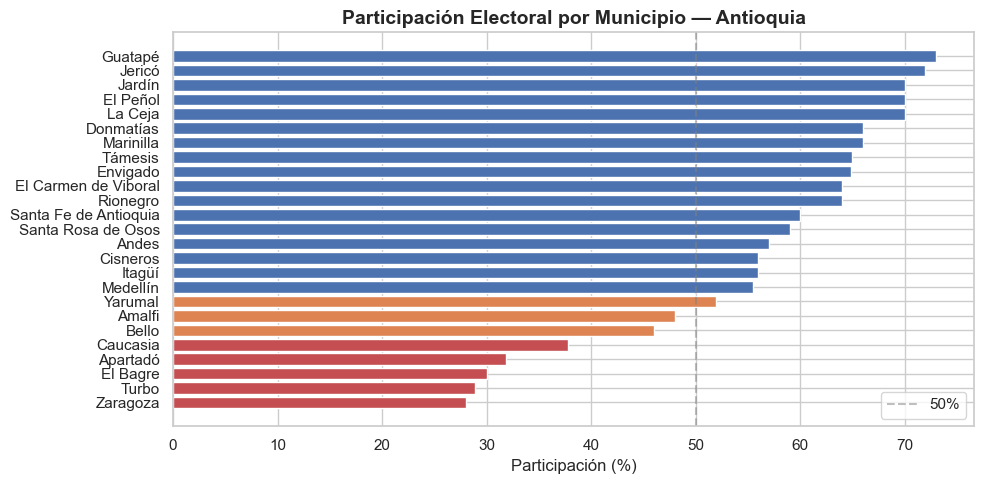

In [226]:
import matplotlib.pyplot as plt

# === Anatomía de un gráfico: paso a paso ===

# 1. Crear el lienzo (figure) y el gráfico (axes)
fig, ax = plt.subplots(figsize=(10, 5))  # Ancho=10, Alto=5 pulgadas

# 2. Dibujar los datos
# Ordenamos para que el gráfico se vea mejor
datos_graf = df.sort_values("participacion_pct", ascending=True)
colores = ["#C44E52" if p < 40 else "#DD8452" if p < 55 else "#4C72B0" 
           for p in datos_graf["participacion_pct"]]

ax.barh(datos_graf["municipio"], datos_graf["participacion_pct"], color=colores, edgecolor="white")

# 3. Personalizar el gráfico
ax.set_title("Participación Electoral por Municipio — Antioquia", fontsize=14, fontweight="bold")
ax.set_xlabel("Participación (%)")
ax.set_ylabel("")
ax.axvline(x=50, color="gray", linestyle="--", alpha=0.5, label="50%")
ax.legend()

# 4. Ajustar y mostrar
plt.tight_layout()
plt.show()

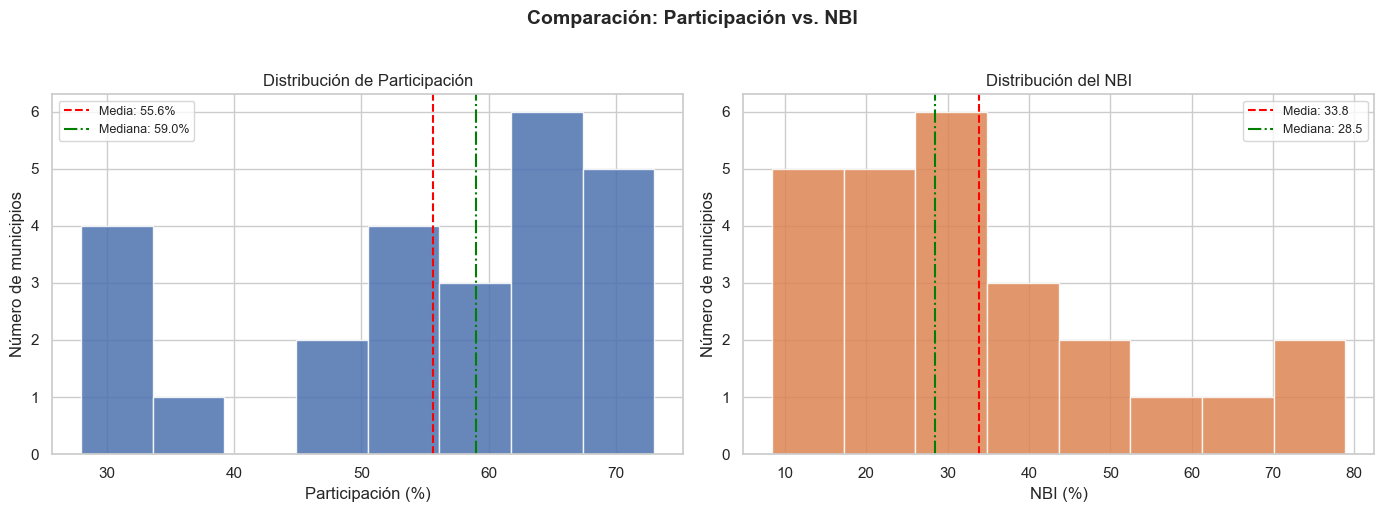

In [227]:
# === Múltiples gráficos en una sola figure: subplots ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas
fig.suptitle("Comparación: Participación vs. NBI", fontsize=14, fontweight="bold", y=1.02)

# Gráfico 1: Participación
axes[0].hist(df["participacion_pct"], bins=8, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribución de Participación")
axes[0].set_xlabel("Participación (%)")
axes[0].set_ylabel("Número de municipios")
axes[0].axvline(df["participacion_pct"].mean(), color="red", linestyle="--", label=f"Media: {df['participacion_pct'].mean():.1f}%")
axes[0].axvline(df["participacion_pct"].median(), color="green", linestyle="-.", label=f"Mediana: {df['participacion_pct'].median():.1f}%")
axes[0].legend(fontsize=9)

# Gráfico 2: NBI
axes[1].hist(df["NBI"], bins=8, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribución del NBI")
axes[1].set_xlabel("NBI (%)")
axes[1].set_ylabel("Número de municipios")
axes[1].axvline(df["NBI"].mean(), color="red", linestyle="--", label=f"Media: {df['NBI'].mean():.1f}")
axes[1].axvline(df["NBI"].median(), color="green", linestyle="-.", label=f"Mediana: {df['NBI'].median():.1f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 📝 TL;DR
- `fig, ax = plt.subplots()` crea un gráfico. `fig, axes = plt.subplots(filas, columnas)` crea varios.
- `ax.bar()`, `ax.barh()`, `ax.hist()`, `ax.scatter()` dibujan distintos tipos de gráficos.
- `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` personalizan etiquetas.
- `ax.axvline()` y `ax.axhline()` agregan líneas de referencia (media, mediana, umbrales).
- `plt.tight_layout()` ajusta los márgenes automáticamente.

---
# Tema 14 — Gráficos de barras y tablas de frecuencia visual

### 🧠 ¿Cuándo usar un gráfico de barras?
- Para representar **variables categóricas** (subregión, partido, clasificación).
- Para comparar **una métrica entre grupos** (NBI promedio por subregión).

### Regla: Variables categóricas → Barras. Variables continuas → Histograma.

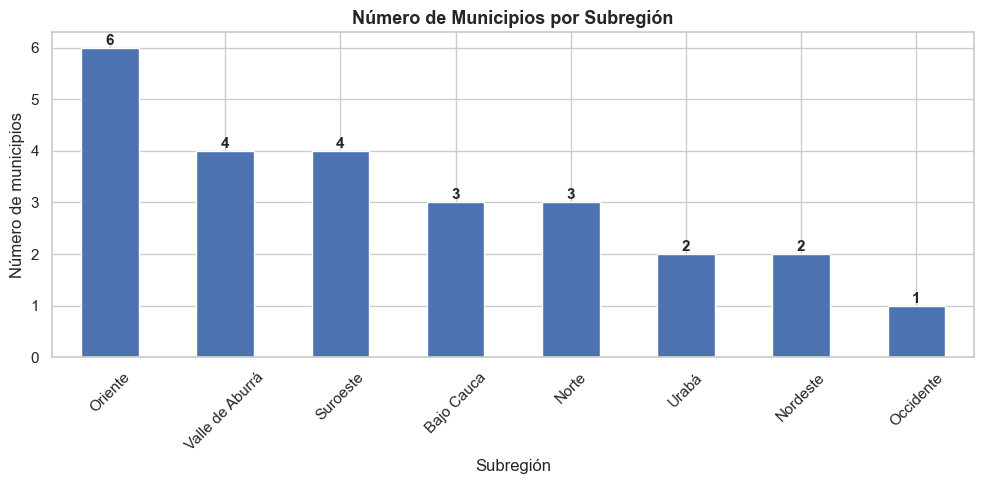

In [228]:
# === Gráfico de barras: frecuencia de municipios por subregión ===

fig, ax = plt.subplots(figsize=(10, 5))

freq = df["subregion"].value_counts()
freq.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")

ax.set_title("Número de Municipios por Subregión", fontsize=13, fontweight="bold")
ax.set_xlabel("Subregión")
ax.set_ylabel("Número de municipios")
ax.tick_params(axis="x", rotation=45)

# Agregar etiquetas de valor sobre cada barra
for barra in ax.patches:
    ax.annotate(f"{barra.get_height():.0f}",
                (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

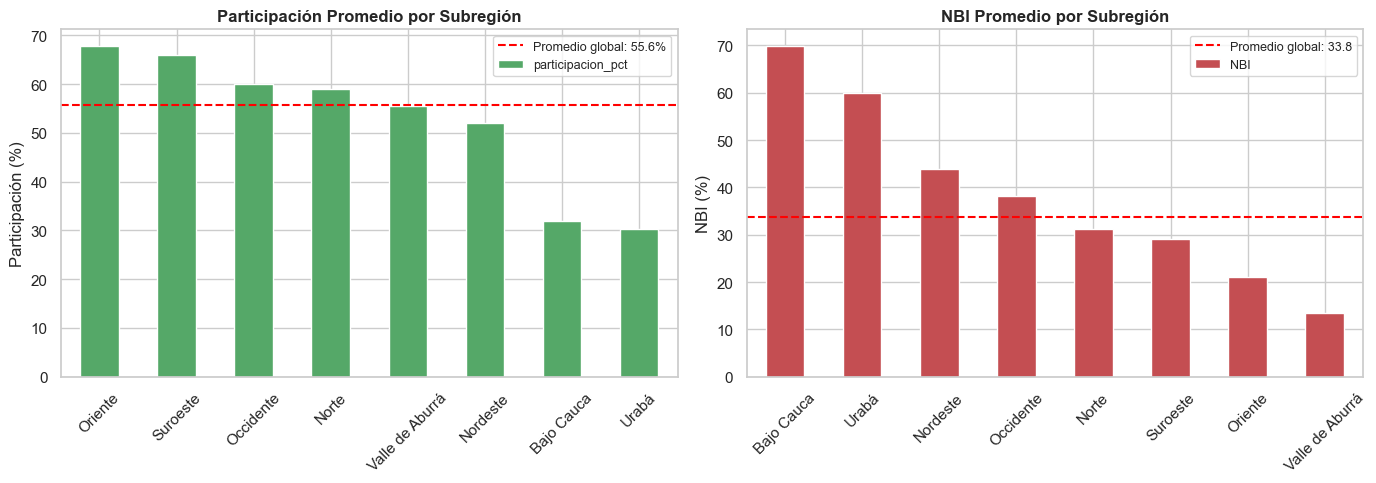

In [229]:
# === Gráfico de barras: comparar una métrica entre grupos ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Participación promedio por subregión
medias_part = df.groupby("subregion")["participacion_pct"].mean().sort_values(ascending=False)
medias_part.plot(kind="bar", ax=axes[0], color="#55A868", edgecolor="white")
axes[0].set_title("Participación Promedio por Subregión", fontweight="bold")
axes[0].set_ylabel("Participación (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(y=df["participacion_pct"].mean(), color="red", linestyle="--", 
                label=f"Promedio global: {df['participacion_pct'].mean():.1f}%")
axes[0].legend(fontsize=9)

# NBI promedio por subregión
medias_nbi = df.groupby("subregion")["NBI"].mean().sort_values(ascending=False)
medias_nbi.plot(kind="bar", ax=axes[1], color="#C44E52", edgecolor="white")
axes[1].set_title("NBI Promedio por Subregión", fontweight="bold")
axes[1].set_ylabel("NBI (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(y=df["NBI"].mean(), color="red", linestyle="--",
                label=f"Promedio global: {df['NBI'].mean():.1f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

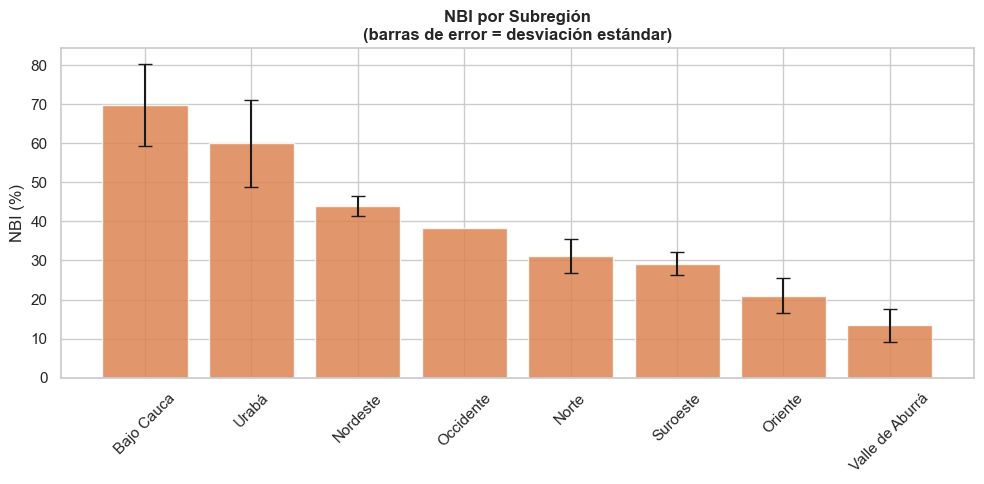

In [230]:
# === Barras con desviación estándar (barras de error) ===
# Esto muestra no solo el promedio sino la dispersión

fig, ax = plt.subplots(figsize=(10, 5))

medias = df.groupby("subregion")["NBI"].mean()
stds = df.groupby("subregion")["NBI"].std()

medias_sorted = medias.sort_values(ascending=False)
stds_sorted = stds[medias_sorted.index]

ax.bar(medias_sorted.index, medias_sorted.values, 
       yerr=stds_sorted.values, capsize=5,
       color="#DD8452", edgecolor="white", alpha=0.85)

ax.set_title("NBI por Subregión\n(barras de error = desviación estándar)", fontweight="bold")
ax.set_ylabel("NBI (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### ⚠️ Desafío
Crea un gráfico de barras que muestre el **total de votantes** por subregión (no el promedio, sino la suma). ¿Qué subregión aporta más votos al total departamental?

### 📝 TL;DR
- `df["col"].value_counts().plot(kind="bar")` → barras de frecuencia.
- `df.groupby("grupo")["var"].mean().plot(kind="bar")` → barras de una métrica por grupo.
- `ax.axhline()` agrega líneas de referencia horizontales.
- `yerr=` agrega barras de error para mostrar la dispersión.

In [231]:
# Tu código aquí


---
# Tema 15 — Boxplots, Histogramas y Seaborn

### 🧠 Conceptos clave

| Gráfico | Qué muestra | Cuándo usarlo |
|---|---|---|
| **Histograma** | Distribución de una variable continua (forma, centro, dispersión) | Explorar cómo se distribuye una variable |
| **Boxplot** | Mediana, cuartiles, IQR y outliers de un vistazo | Comparar distribuciones entre grupos |
| **Seaborn** | Librería que extiende matplotlib con gráficos estadísticos más elegantes | Cuando quieres gráficos listos para publicar |

### 🎯 ¿Cómo leer un boxplot?
```
              ┌─────────────────────┐
     ╶────────┤     │         │     ├────────╴
              └─────────────────────┘
     ↑        ↑     ↑         ↑     ↑        ↑
  Outliers  Bigote  Q1     Mediana  Q3     Bigote
           (min*)                          (max*)
```
- La **caja** contiene el 50% central de los datos (IQR).
- La **línea dentro de la caja** es la mediana.
- Los **bigotes** se extienden hasta 1.5 × IQR.
- Los **puntos fuera de los bigotes** son valores atípicos (outliers).

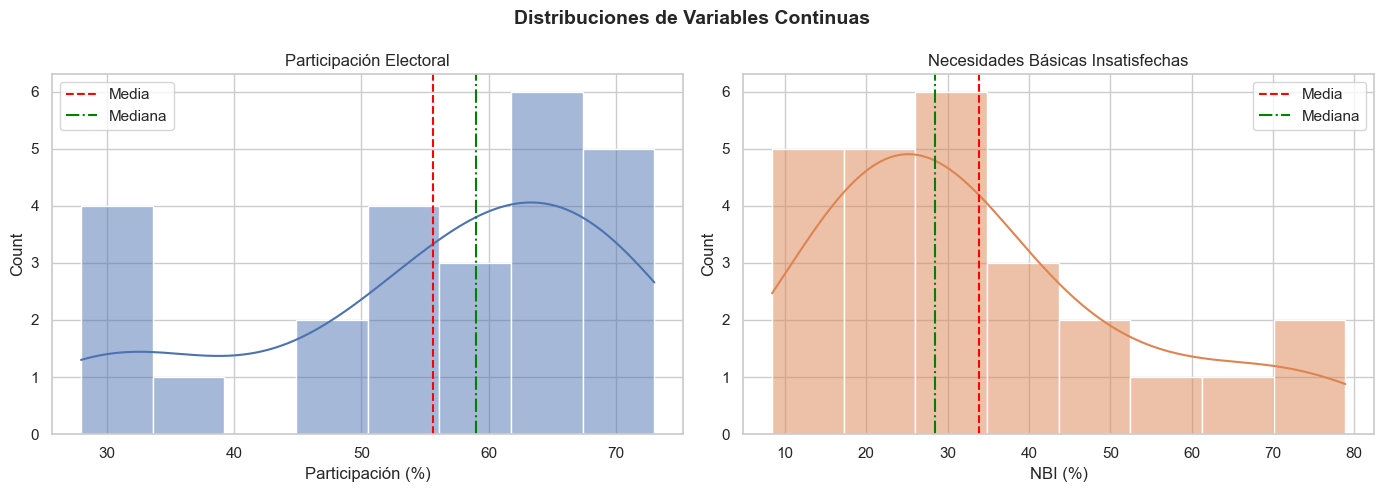

In [232]:
import seaborn as sns

# Configuración global de seaborn
sns.set_theme(style="whitegrid", palette="muted")

# === Histograma con seaborn: más elegante que matplotlib puro ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuciones de Variables Continuas", fontsize=14, fontweight="bold")

# Histograma de participación con curva de densidad
sns.histplot(df["participacion_pct"], bins=8, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Participación Electoral")
axes[0].set_xlabel("Participación (%)")
axes[0].axvline(df["participacion_pct"].mean(), color="red", linestyle="--", label="Media")
axes[0].axvline(df["participacion_pct"].median(), color="green", linestyle="-.", label="Mediana")
axes[0].legend()

# Histograma de NBI
sns.histplot(df["NBI"], bins=8, kde=True, color="#DD8452", ax=axes[1])
axes[1].set_title("Necesidades Básicas Insatisfechas")
axes[1].set_xlabel("NBI (%)")
axes[1].axvline(df["NBI"].mean(), color="red", linestyle="--", label="Media")
axes[1].axvline(df["NBI"].median(), color="green", linestyle="-.", label="Mediana")
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/9_/14xzl0r10jx3tbp900s5_5jw0000gn/T/ipykernel_88168/111505959.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="subregion", y="participacion_pct", order=orden,


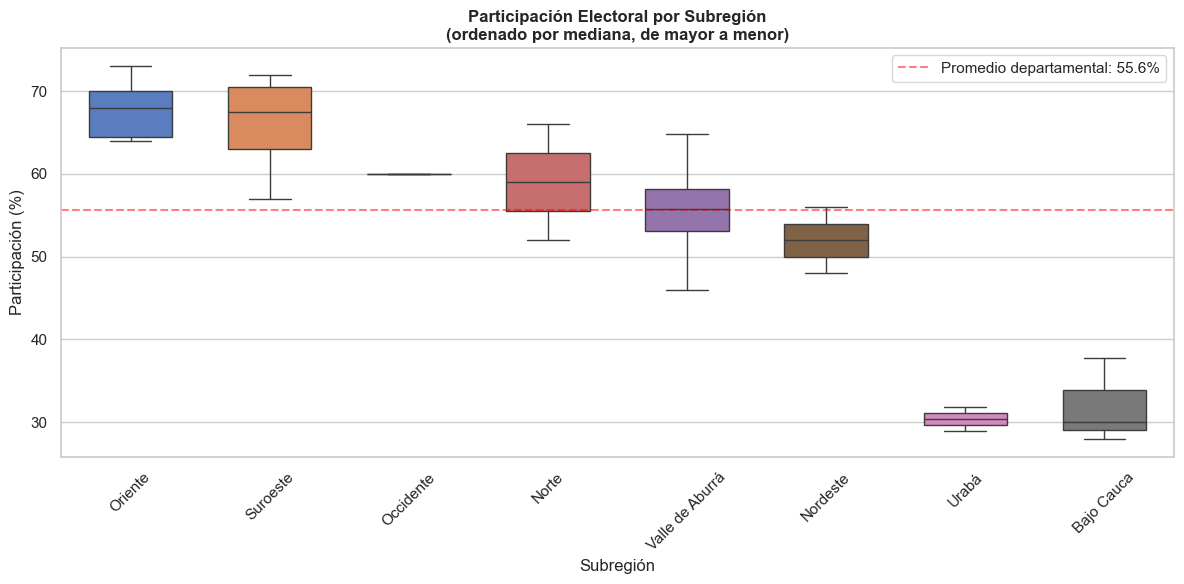

In [233]:
# === Boxplot: comparar distribuciones entre grupos ===

fig, ax = plt.subplots(figsize=(12, 6))

# Ordenar subregiones por mediana de participación (de mayor a menor)
orden = df.groupby("subregion")["participacion_pct"].median().sort_values(ascending=False).index

sns.boxplot(data=df, x="subregion", y="participacion_pct", order=orden,
            palette="muted", width=0.6, ax=ax)

ax.set_title("Participación Electoral por Subregión\n(ordenado por mediana, de mayor a menor)",
             fontweight="bold")
ax.set_xlabel("Subregión")
ax.set_ylabel("Participación (%)")
ax.tick_params(axis="x", rotation=45)

# Línea de referencia: promedio departamental
ax.axhline(y=df["participacion_pct"].mean(), color="red", linestyle="--", alpha=0.5,
           label=f"Promedio departamental: {df['participacion_pct'].mean():.1f}%")
ax.legend()

plt.tight_layout()
plt.show()

/var/folders/9_/14xzl0r10jx3tbp900s5_5jw0000gn/T/ipykernel_88168/1230415124.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="presencia_armada", y="participacion_pct",
/var/folders/9_/14xzl0r10jx3tbp900s5_5jw0000gn/T/ipykernel_88168/1230415124.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="presencia_armada", y="NBI",


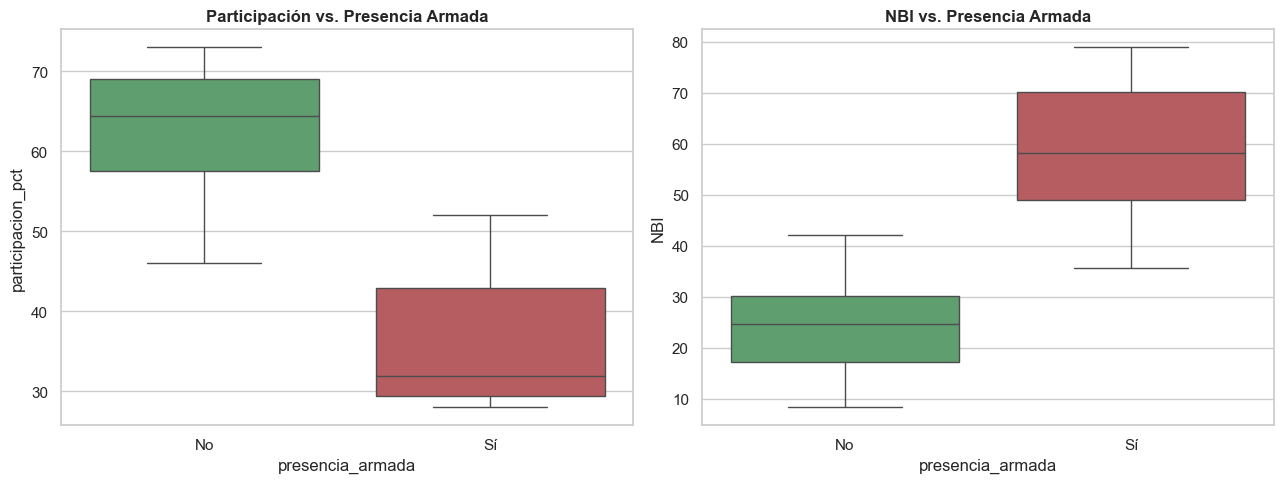

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

paleta = {"True": "#C44E52", "False": "#55A868"} 

# Gráfico 1
sns.boxplot(data=df, x="presencia_armada", y="participacion_pct",
            palette=paleta, ax=axes[0])
axes[0].set_title("Participación vs. Presencia Armada", fontweight="bold")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No", "Sí"])

# Gráfico 2
sns.boxplot(data=df, x="presencia_armada", y="NBI",
            palette=paleta, ax=axes[1])
axes[1].set_title("NBI vs. Presencia Armada", fontweight="bold")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No", "Sí"])

plt.tight_layout()
plt.show()

### ⚠️ Desafío
Crea un boxplot que compare el `indice_ruralidad` entre las subregiones. ¿Cuál es la subregión más rural? ¿Y la más urbana?

### 📝 TL;DR
- `sns.histplot(data, kde=True)` → histograma con curva de densidad.
- `sns.boxplot(data=df, x="grupo", y="variable")` → boxplots comparativos.
- El boxplot muestra mediana, cuartiles, IQR y outliers de un vistazo.
- `sns.set_theme(style="whitegrid")` configura el estilo visual globalmente.

In [235]:
# Tu código aquí


---
# Tema 16 — Scatterplots y Mapas de Calor de Correlación

### 🧠 ¿Cuándo usar cada uno?

| Gráfico | Qué muestra | Cuándo usarlo |
|---|---|---|
| **Scatterplot** | Relación entre dos variables continuas. Cada punto es una observación. | Explorar si dos variables se mueven juntas. |
| **Mapa de calor** | Todas las correlaciones en una sola visualización. Colores indican fuerza y dirección. | Identificar rápidamente qué variables están relacionadas. |

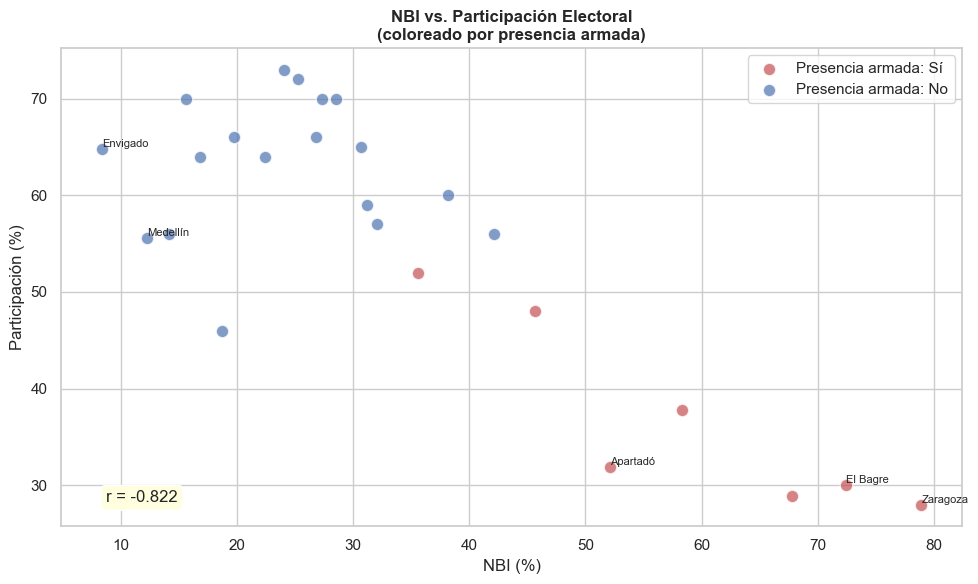

In [236]:
# === Scatterplot: NBI vs. Participación ===

fig, ax = plt.subplots(figsize=(10, 6))

# Colorear por presencia armada
colores_scatter = {True: "#C44E52", False: "#4C72B0"}

for grupo, color in colores_scatter.items():
    subset = df[df["presencia_armada"] == grupo]
    ax.scatter(subset["NBI"], subset["participacion_pct"],
               c=color, s=80, alpha=0.7, edgecolors="white",
               label=f"Presencia armada: {'Sí' if grupo else 'No'}")

# Etiquetar algunos municipios clave
for _, row in df.iterrows():
    if row["municipio"] in ["Medellín", "Apartadó", "Zaragoza", "Envigado", "El Bagre"]:
        ax.annotate(row["municipio"], (row["NBI"], row["participacion_pct"]),
                   fontsize=8, ha="left", va="bottom")

ax.set_title("NBI vs. Participación Electoral\n(coloreado por presencia armada)", fontweight="bold")
ax.set_xlabel("NBI (%)")
ax.set_ylabel("Participación (%)")
ax.legend()

# Correlación como anotación
r = df["NBI"].corr(df["participacion_pct"])
ax.text(0.05, 0.05, f"r = {r:.3f}", transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

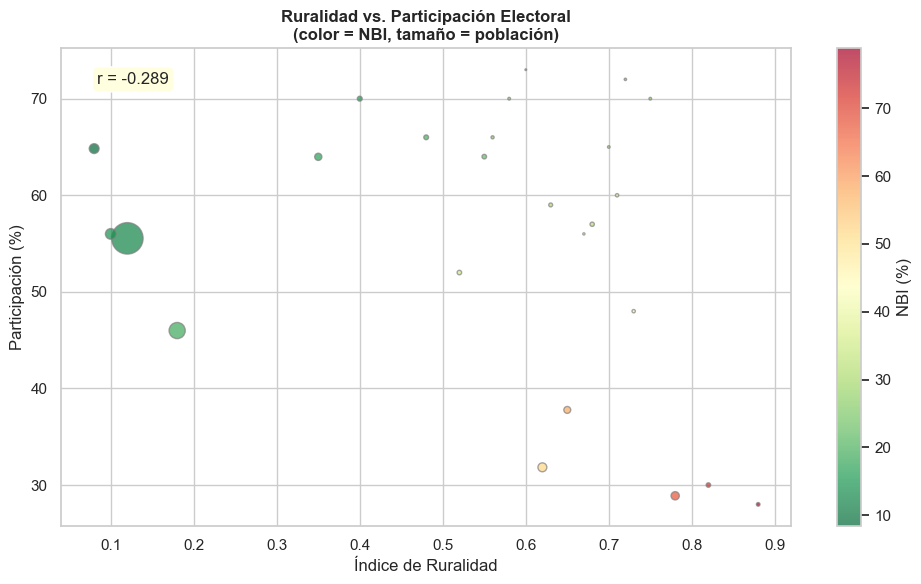

💡 Este gráfico muestra 4 variables a la vez:
   Eje X = ruralidad, Eje Y = participación, Color = NBI, Tamaño = población


In [237]:
# === Scatterplot: Ruralidad vs. Participación ===

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df["indice_ruralidad"], df["participacion_pct"],
                     c=df["NBI"], cmap="RdYlGn_r", s=df["poblacion"]/5000,
                     alpha=0.7, edgecolors="gray")

# Barra de color para el NBI
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("NBI (%)")

ax.set_title("Ruralidad vs. Participación Electoral\n(color = NBI, tamaño = población)", fontweight="bold")
ax.set_xlabel("Índice de Ruralidad")
ax.set_ylabel("Participación (%)")

r = df["indice_ruralidad"].corr(df["participacion_pct"])
ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes, fontsize=12, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

plt.tight_layout()
plt.show()

print("💡 Este gráfico muestra 4 variables a la vez:")
print("   Eje X = ruralidad, Eje Y = participación, Color = NBI, Tamaño = población")

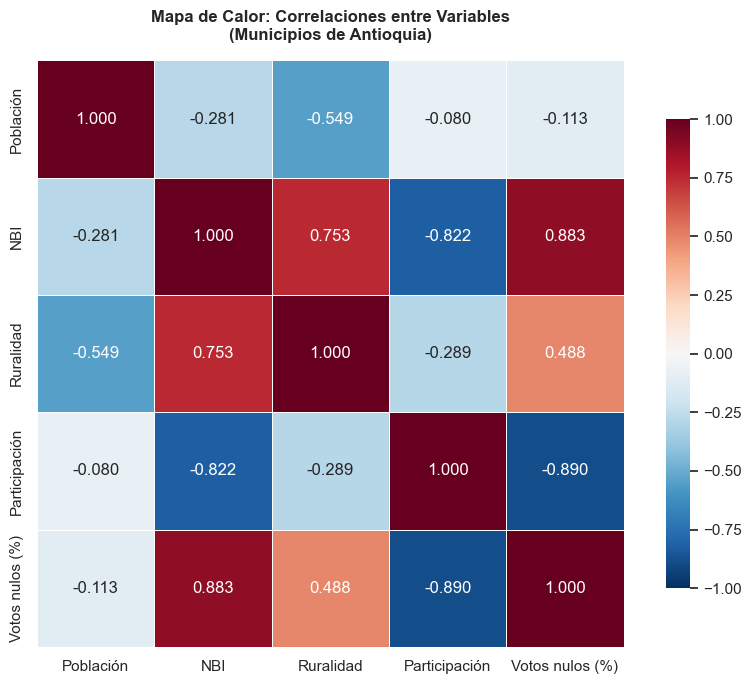

💡 Cómo leer el mapa de calor:
   - Rojo intenso = correlación positiva fuerte
   - Azul intenso = correlación negativa fuerte
   - Blanco/pálido = poca o ninguna correlación


In [238]:
# === Mapa de calor de correlaciones ===

fig, ax = plt.subplots(figsize=(9, 7))

vars_corr = ["poblacion", "NBI", "indice_ruralidad", "participacion_pct", "nulos_pct"]
matriz = df[vars_corr].corr().round(3)

# Renombrar para que el gráfico sea más legible
nombres_bonitos = ["Población", "NBI", "Ruralidad", "Participación", "Votos nulos (%)"]
matriz.index = nombres_bonitos
matriz.columns = nombres_bonitos

sns.heatmap(matriz, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("Mapa de Calor: Correlaciones entre Variables\n(Municipios de Antioquia)",
             fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

print("💡 Cómo leer el mapa de calor:")
print("   - Rojo intenso = correlación positiva fuerte")
print("   - Azul intenso = correlación negativa fuerte")
print("   - Blanco/pálido = poca o ninguna correlación")

### ⚠️ Desafío
1. Crea un scatterplot de `poblacion` vs. `votantes`. ¿Qué patrón esperas encontrar? ¿La correlación es fuerte?
2. Agrega al mapa de calor la variable `abstencion_pct`. ¿Qué pasa con la correlación entre participación y abstención? ¿Por qué?

### 📝 TL;DR
- `ax.scatter(x, y)` → scatterplot. Cada punto = una observación.
- Puedes codificar más variables con `c=` (color) y `s=` (tamaño).
- `sns.heatmap(df.corr(), annot=True)` → mapa de calor de correlaciones.
- Rojo = positiva, Azul = negativa, Blanco = sin relación.

In [239]:
# Tu código aquí


---
# 🎓 Cierre del Cuaderno

¡Felicidades! Has completado los 16 temas fundamentales de pandas, visualización y estadística descriptiva. Ahora tienes las herramientas para:

- **Cargar y explorar** cualquier dataset con pandas.
- **Seleccionar, filtrar y transformar** datos para responder preguntas específicas.
- **Calcular e interpretar** media, mediana, moda, desviación estándar, varianza, cuartiles, percentiles, sesgo y correlación.
- **Visualizar** distribuciones con histogramas, comparar grupos con boxplots, explorar relaciones con scatterplots y resumir correlaciones con mapas de calor.
- **Comparar grupos** usando `groupby()` y `agg()`: la herramienta central del análisis político comparado.

---

### 🔄 Resumen de flujo de trabajo

```
1. CARGAR     → pd.read_csv() → head(), shape, info(), isnull()
2. EXPLORAR   → describe(), value_counts() → ¿qué tengo?
3. CLASIFICAR → ¿Cuáles son numéricas? ¿Cuáles categóricas?
4. CALCULAR   → mean(), median(), std(), quantile() → describe cada variable
5. COMPARAR   → groupby().agg() + boxplots → ¿hay diferencias entre grupos?
6. RELACIONAR → corr() + scatterplots + heatmap → ¿qué se mueve junto?
7. INTERPRETAR → El valor añadido del politólogo: ¿qué significa esto?
```

### 🚀 Próximo paso
Con estos fundamentos, estás listo/a para enfrentar un análisis descriptivo completo con un dataset real.

---
## 📚 Referencia Rápida

### Pandas esencial
```python
import pandas as pd

# Cargar datos
df = pd.read_csv("archivo.csv")

# Inspeccionar
df.head()                      # Primeras filas
df.shape                       # (filas, columnas)
df.dtypes                      # Tipos de datos
df.info()                      # Resumen completo
df.isnull().sum()              # Valores faltantes
df.describe()                  # Estadísticos descriptivos
df["col"].value_counts()       # Tabla de frecuencias

# Seleccionar y filtrar
df["columna"]                  # Una columna (Series)
df[["col1", "col2"]]           # Varias columnas (DataFrame)
df[df["col"] > valor]          # Filtro booleano
df[(cond1) & (cond2)]          # Múltiples condiciones
df["col"].isin(["a", "b"])     # Pertenencia a lista

# Crear columnas
df["nueva"] = df["a"] / df["b"] * 100
df["cat"] = np.select(condiciones, categorias)
df["col"].apply(funcion)

# Agrupar y comparar
df.groupby("grupo")["var"].mean()
df.groupby("grupo")["var"].agg(Media="mean", Mediana="median", Desv="std", N="count")

# Ordenar
df.sort_values("col", ascending=False)
df.nlargest(5, "col")
```

### Estadísticos
```python
serie.mean()              # Media
serie.median()            # Mediana
serie.mode()              # Moda
serie.std()               # Desviación estándar
serie.var()               # Varianza
serie.skew()              # Sesgo
serie.quantile(0.75)      # Percentil 75 (Q3)
serie.corr(otra_serie)    # Correlación de Pearson
df[vars].corr()           # Matriz de correlación
```

### Visualización
```python
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(datos, bins=10)                   # Histograma
ax.bar(categorias, valores)               # Barras
ax.scatter(x, y, c=color, s=tamaño)       # Scatterplot
sns.boxplot(data=df, x="grupo", y="var")  # Boxplot comparativo
sns.heatmap(df.corr(), annot=True)        # Mapa de calor
plt.tight_layout()
plt.show()
```